In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model, Model
import autokeras as ak
import pandas as pd
from typing import Optional, Literal
import ast
import gc
import os
import re
from PIL import Image
from visualize_utils import get_best_run_id, extract_model_path, load_autokeras_model

In [73]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

supxlabel_fontsize = 20
supylabel_fontsize = 20

In [74]:
def preprocess_image(file_path: str) -> tf.Tensor:
    image = tf.io.read_file(file_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE[0], IMG_SIZE[1]])
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    return image

In [75]:
def analyze_feature_distribution(features, labels, class_names=None):
    """
    特徴量の分布を分析
    """
    print("\n=== Feature Analysis ===")
    print(f"Feature dimensions: {features.shape[1]}")
    print(f"Number of samples: {features.shape[0]}")
    print(f"Number of classes: {len(np.unique(labels))}")
    
    # クラス別統計
    unique_labels = np.unique(labels)
    for label in unique_labels:
        mask = labels == label
        count = np.sum(mask)
        class_name = class_names[int(label)] if class_names else f'Class {int(label)}'
        print(f"{class_name}: {count} samples ({count/len(labels)*100:.1f}%)")

In [76]:
cls_results_path = "./automl_cls_results.csv"
reg_results_path = "./automl_reg_results.csv"
df_reg = pd.read_csv(reg_results_path)
df_reg = df_reg[df_reg["batch_size"] < 65]
df_cls = pd.read_csv(cls_results_path)
df_cls = df_cls[df_cls["batch_size"] < 65]

In [77]:
df_cls_ak = df_cls[(df_cls["ak_seed"] == 42) & (df_cls["max_trials"] == 100)]
df_reg_ak = df_reg[(df_reg["ak_seed"] == 42) & (df_reg["max_trials"] == 100)]

In [78]:
ak_bbbp_run_id = get_best_run_id(df_cls_ak, "BBBP", "roc_auc", "max", "autokeras", is_daug=True)
imgmol_bbbp_run_id = get_best_run_id(df_cls, "BBBP", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

ak_pgp_run_id = get_best_run_id(df_cls_ak, "P-gp", "roc_auc", "max", "autokeras", is_daug=True)
imgmol_pgp_run_id = get_best_run_id(df_cls, "P-gp", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

ak_cyp_run_id = get_best_run_id(df_cls_ak, "CYP3A4", "roc_auc", "max", "autokeras", is_daug=True)
imgmol_cyp_run_id = get_best_run_id(df_cls, "CYP3A4", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

ak_herg_run_id = get_best_run_id(df_cls_ak, "hERG", "roc_auc", "max", "autokeras", is_daug=True)
imgmol_herg_run_id = get_best_run_id(df_cls, "hERG", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

model_name: autokeras
✅ 最適なRun ID: b27a1cc084bb4e86a9f33f8085f81e8e
   model_name: autokeras
   target: BBBP
   roc_auc: 0.8860412637008381
model_name: ImageMol
✅ 最適なRun ID: df3aeb990f484bc5b29e13e9f862a78f
   model_name: ImageMol
   target: BBBP
   roc_auc: 0.9234723117701842
model_name: autokeras
✅ 最適なRun ID: 09f1665b9ff34511872d0f2e4c1594db
   model_name: autokeras
   target: P-gp
   roc_auc: 0.8402621305075292
model_name: ImageMol
✅ 最適なRun ID: b87f22fa40a842f6a8ffae9b459f2e15
   model_name: ImageMol
   target: P-gp
   roc_auc: 0.8570998326826548
model_name: autokeras
✅ 最適なRun ID: 09b63db7ea4d4a17b274075787db53cb
   model_name: autokeras
   target: CYP3A4
   roc_auc: 0.8571937069398211
model_name: ImageMol
✅ 最適なRun ID: 72273f97066f424c9ee23914e5eec58d
   model_name: ImageMol
   target: CYP3A4
   roc_auc: 0.8854444012816916
model_name: autokeras
✅ 最適なRun ID: e8033a8fd47d4192b24bdad6bf8678f7
   model_name: autokeras
   target: hERG
   roc_auc: 0.8146133561462614
model_name: ImageMol
✅

/chemAutoVision/src/notebooks/visualize_utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model_name"] = df["model_name"].replace(["None", "nan", "NaN"], None)
/chemAutoVision/src/notebooks/visualize_utils.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[metric] = filtered_df[metric].astype(str).str.strip("'")
/chemAutoVision/src/notebooks/visualize_utils.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [79]:
bbbp_ak_model_path = extract_model_path(cls_results_path, ak_bbbp_run_id)
pgp_ak_model_path = extract_model_path(cls_results_path, ak_pgp_run_id)
herg_ak_model_path = extract_model_path(cls_results_path, ak_herg_run_id)
cyp_ak_model_path = extract_model_path(cls_results_path, ak_cyp_run_id)

bbbp_imgmol_model_path = extract_model_path(cls_results_path, imgmol_bbbp_run_id)
pgp_imgmol_model_path = extract_model_path(cls_results_path, imgmol_pgp_run_id)
herg_imgmol_model_path = extract_model_path(cls_results_path, imgmol_herg_run_id)
cyp_imgmol_model_path = extract_model_path(cls_results_path, imgmol_cyp_run_id)

bbbp_data_path = "../../data/BBBP_img.pkl"
pgp_data_path = "../../data/P-gp_img.pkl"
herg_data_path = "../../data/hERG_img.pkl"
cyp_data_path = "../../data/CYP3A4_img.pkl"


In [80]:
IMG_SIZE = (256, 256, 3)

In [81]:
# 回帰モデル
ak_freesolv_run_id = get_best_run_id(df_reg_ak, "FreeSolv", "r2", "max", "autokeras", is_daug=True)
ak_delaney_run_id = get_best_run_id(df_reg_ak, "Dalaney", "r2", "max", "autokeras", is_daug=True)
ak_lipo_run_id = get_best_run_id(df_reg_ak, "Lipo", "r2", "max", "autokeras", is_daug=True)

freesolv_ak_model_path = extract_model_path(reg_results_path, ak_freesolv_run_id)
delaney_ak_model_path = extract_model_path(reg_results_path, ak_delaney_run_id)
lipo_ak_model_path = extract_model_path(reg_results_path, ak_lipo_run_id)

model_name: autokeras
✅ 最適なRun ID: ffbfed5cdfab4ceeb81623aadb0f1ea3
   model_name: autokeras
   target: FreeSolv
   r2: 0.8800897212803409
model_name: autokeras
✅ 最適なRun ID: 7f14129b17cc4e469c7cd57abbf0766a
   model_name: autokeras
   target: Dalaney
   r2: 0.8649024296884741
model_name: autokeras
✅ 最適なRun ID: 1f69eae575b4485283db71df7226d801
   model_name: autokeras
   target: Lipo
   r2: 0.6289607545924005


/chemAutoVision/src/notebooks/visualize_utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model_name"] = df["model_name"].replace(["None", "nan", "NaN"], None)
/chemAutoVision/src/notebooks/visualize_utils.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[metric] = filtered_df[metric].astype(str).str.strip("'")
/chemAutoVision/src/notebooks/visualize_utils.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [82]:
# 分類モデル
# autokeras
bbbp_original_model_ak = load_autokeras_model(bbbp_ak_model_path)
pgp_original_model_ak = load_autokeras_model(pgp_ak_model_path)
herg_original_model_ak = load_autokeras_model(herg_ak_model_path)
cyp_original_model_ak = load_autokeras_model(cyp_ak_model_path)

Loading AutoKeras model from ../../models/BBBP_classify_autokeras_20260309135922.h5...

=== Model Structure Analysis ===
Number of inputs: 1
Input shapes: [TensorShape([None, 256, 256, 3])]
Input names: ['input_1']

=== Layer Connections ===
Layer 0: input_1 (InputLayer)
  Input shape: [(None, 256, 256, 3)]
  Output shape: [(None, 256, 256, 3)]
Layer 1: cast_to_float32 (CastToFloat32)
  Input shape: (None, 256, 256, 3)
  Output shape: (None, 256, 256, 3)
Layer 2: random_translation (RandomTranslation)
  Input shape: (None, 256, 256, 3)
  Output shape: (None, 256, 256, 3)
Layer 3: random_rotation (RandomRotation)
  Input shape: (None, 256, 256, 3)
  Output shape: (None, 256, 256, 3)
Layer 4: resnet50 (Functional)
  Input spec: [InputSpec(shape=(None, None, None, 3), ndim=4)]
  Input shape: (None, None, None, 3)
  Output shape: (None, None, None, 2048)
Layer 5: global_average_pooling2d (GlobalAveragePooling2D)
  Input spec: InputSpec(ndim=4)
  Input shape: (None, 8, 8, 2048)
  Output sha

# モデル性能の可視化

In [83]:
def plot_actual_predicted(df, ax=None, title='Actual vs Predicted', min_val=None, max_val=None):
    """
    実際値と予測値の散布図を描画する関数
    
    Parameters:
    df: DataFrame - 'y_test'と'y_preds'列を含むデータフレーム
    ax: matplotlib.axes.Axes - サブプロット用のaxesオブジェクト（Noneの場合は新しい図を作成）
    title: str - グラフのタイトル
    min_val: float - 軸の最小値（Noneの場合は自動計算）
    max_val: float - 軸の最大値（Noneの場合は自動計算）
    
    Returns:
    ax: matplotlib.axes.Axes - axesオブジェクト
    """
    # axが指定されていない場合は新しい図を作成
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    
    # 散布図の作成
    if 'y_true' in df.columns:
        actual_col = 'y_true'
    elif 'y_test' in df.columns:
        actual_col = 'y_test'
    else:
        raise Error("actual column is not exist in df")
    ax.scatter(df[actual_col], df['y_preds'], color='blue', s=5, alpha=0.6)
    
    # min_val, max_valが指定されていない場合は自動計算
    if min_val is None:
        min_val = min(df[actual_col].min(), df['y_preds'].min())
    if max_val is None:
        max_val = max(df[actual_col].max(), df['y_preds'].max())
    
    # y = x ライン（理想的な予測）を追加
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    # グラフの設定
    ax.set_title(title)
    # ax.set_xlabel('Actual Values')
    # ax.set_ylabel('Predicted Values')
    ax.grid(True, alpha=0.3)
    
    # 軸の範囲を設定
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    ticks = np.arange(int(min_val), int(max_val)+1, 1)  # 1刻みで設定
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    
    return ax

In [84]:
def get_row_with_id(df, run_id):
    return df[df["Run ID"]==run_id]

In [85]:
def extract_metric_score(result_df, metric):
    if not result_df.empty and metric in result_df.columns:
        return result_df[metric].iloc[0]
    else:
        raise ValueError(f"{metric} column is not exist")

In [86]:
def create_result_df(
    results_csv_path: str, 
    model_name: str, 
    run_id: str,
    target: str
):

    df_results = pd.read_csv(results_csv_path)
    result_row = df_results[df_results["Run ID"]==run_id]
    print(result_row.result_csv_path.iloc[0])
    if model_name == "autokeras" or model_name == "cnn":
        print(f"result_csv_path: {result_row.result_csv_path.iloc[0]}")
        df_result = pd.read_csv(result_row.result_csv_path.iloc[0].replace("../results", "../../results"))
    elif model_name == "ImageMol":
        print(f"result_csv_path: {result_row.result_csv_path.iloc[0]}")
        df_result = pd.read_csv(result_row.result_csv_path.iloc[0].replace("./results", "../../results"))
    elif model_name == "chemprops":
        y_preds = pd.read_csv(result_row.result_csv_path.iloc[0].replace("././graph_hyperopt", "../graph_hyperopt"))[target]
        y_true = pd.read_csv(f"../../data/test_{target}_img.csv")[target]
        df_result = pd.DataFrame({
                    'y_true': y_true,
                    'y_preds': y_preds
                })
    elif model_name == "HyperoptEstimator":
        df_result = pd.read_csv(result_row.result_csv_path.iloc[0].replace("./results", "../../results"))
        
    return df_result


In [87]:
ak_freesolv_run_id = get_best_run_id(df_reg_ak, "FreeSolv", "rmse", "min", "autokeras", is_daug=True)
resnet_nodaug_freesolv_run_id = get_best_run_id(df_reg_ak, "FreeSolv", "rmse", "min", "resnet18", is_daug=False)
resnet_daug_freesolv_run_id = get_best_run_id(df_reg_ak, "FreeSolv", "rmse", "min", "resnet18", is_daug=True)
imgmol_freesolv_run_id = get_best_run_id(df_reg, "FreeSolv", "rmse", "min", "ImageMol")

ak_lipo_run_id = get_best_run_id(df_reg_ak, "Lipo", "rmse", "min", "autokeras", is_daug=True)
resnet_nodaug_lipo_run_id = get_best_run_id(df_reg_ak, "Lipo", "rmse", "min", "resnet18", is_daug=False)
resnet_daug_lipo_run_id = get_best_run_id(df_reg_ak, "Lipo", "rmse", "min", "resnet18", is_daug=True)
imgmol_lipo_run_id = get_best_run_id(df_reg, "Lipo", "rmse", "min", "ImageMol")

ak_dalaney_run_id = get_best_run_id(df_reg_ak, "Dalaney", "rmse", "min", "autokeras", is_daug=True) 
resnet_nodaug_dalaney_run_id = get_best_run_id(df_reg_ak, "Dalaney", "rmse", "min", "resnet18", is_daug=False)
resnet_daug_dalaney_run_id = get_best_run_id(df_reg_ak, "Dalaney", "rmse", "min", "resnet18", is_daug=True)
imgmol_dalaney_run_id = get_best_run_id(df_reg, "Dalaney", "rmse", "min", "ImageMol")

model_name: autokeras
✅ 最適なRun ID: ffbfed5cdfab4ceeb81623aadb0f1ea3
   model_name: autokeras
   target: FreeSolv
   rmse: 0.3556180455472849
model_name: resnet18
✅ 最適なRun ID: b9670bb82f234f4883af3d1926aeb07e
   model_name: resnet18
   target: FreeSolv
   rmse: 0.8420019450776074
model_name: resnet18
✅ 最適なRun ID: c7cfc185e8e44b1f8d244c229a6de4ed
   model_name: resnet18
   target: FreeSolv
   rmse: 0.713460410176829
model_name: ImageMol
✅ 最適なRun ID: 278db1879c014d02b2f587b573b482f3
   model_name: ImageMol
   target: FreeSolv
   rmse: 0.3124640933985353
model_name: autokeras
✅ 最適なRun ID: 1f69eae575b4485283db71df7226d801
   model_name: autokeras
   target: Lipo
   rmse: 0.5916122330429369
model_name: resnet18
✅ 最適なRun ID: 77987dd3bc0f47588bb9dd2629a4ef1d
   model_name: resnet18
   target: Lipo
   rmse: 0.878657506028395
model_name: resnet18
✅ 最適なRun ID: 43c5cf6bd7a84e21adb2371449bd6de7
   model_name: resnet18
   target: Lipo
   rmse: 0.8364183952550409
model_name: ImageMol
✅ 最適なRun ID: 3b6

/chemAutoVision/src/notebooks/visualize_utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model_name"] = df["model_name"].replace(["None", "nan", "NaN"], None)
/chemAutoVision/src/notebooks/visualize_utils.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[metric] = filtered_df[metric].astype(str).str.strip("'")
/chemAutoVision/src/notebooks/visualize_utils.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [88]:
df_freesolv_ak_results = create_result_df(reg_results_path, "autokeras", ak_freesolv_run_id, "FreeSolv")
df_freesolv_resnet_nodaug_results = create_result_df(reg_results_path, "autokeras", resnet_nodaug_freesolv_run_id, "FreeSolv")
df_freesolv_resnet_daug_results = create_result_df(reg_results_path, "autokeras", resnet_daug_freesolv_run_id, "FreeSolv")
df_freesolv_imgmol_results = create_result_df(reg_results_path, "ImageMol", imgmol_freesolv_run_id, "freesolv")

df_lipo_ak_results = create_result_df(reg_results_path, "autokeras", ak_lipo_run_id, "Lipo")
df_lipo_resnet_nodaug_results = create_result_df(reg_results_path, "autokeras", resnet_nodaug_lipo_run_id, "Lipo")
df_lipo_resnet_daug_results = create_result_df(reg_results_path, "autokeras", resnet_daug_lipo_run_id, "Lipo")
df_lipo_imgmol_results = create_result_df(reg_results_path, "ImageMol", imgmol_lipo_run_id, "Lipo")

df_dalaney_ak_results = create_result_df(reg_results_path, "autokeras", ak_dalaney_run_id, "Dalaney")
df_dalaney_resnet_nodaug_results = create_result_df(reg_results_path, "autokeras", resnet_nodaug_dalaney_run_id, "Dalaney")
df_dalaney_resnet_daug_results = create_result_df(reg_results_path, "autokeras", resnet_daug_dalaney_run_id, "Dalaney")
df_dalaney_imgmol_results = create_result_df(reg_results_path, "ImageMol", imgmol_dalaney_run_id, "Dalaney")

../results/FreeSolv_regression_autokeras_20260310133108.csv
result_csv_path: ../results/FreeSolv_regression_autokeras_20260310133108.csv
../results/FreeSolv_regression_resnet18_20260410144952.csv
result_csv_path: ../results/FreeSolv_regression_resnet18_20260410144952.csv
../results/FreeSolv_regression_resnet18_20260414051327.csv
result_csv_path: ../results/FreeSolv_regression_resnet18_20260414051327.csv
./results/freesolv_regression_ImageMol_20260302144144.csv
result_csv_path: ./results/freesolv_regression_ImageMol_20260302144144.csv
../results/Lipo_regression_autokeras_20260316112024.csv
result_csv_path: ../results/Lipo_regression_autokeras_20260316112024.csv
../results/Lipo_regression_resnet18_20260410233310.csv
result_csv_path: ../results/Lipo_regression_resnet18_20260410233310.csv
../results/Lipo_regression_resnet18_20260413151040.csv
result_csv_path: ../results/Lipo_regression_resnet18_20260413151040.csv
./results/Lipo_regression_ImageMol_20260302144353.csv
result_csv_path: ./resu

In [89]:
datasets = ['FreeSolv', 'ESOL', 'Lipo']
models = ['ResNet18(w/o Aug)', 'ResNet18(w/ Aug)', 'ImageMol', 'ChemAutoVision']
model_display_names = [ 
    'ResNet18(w/o Aug)',
    'ResNet18(w/ Aug)',
    'ImageMol', 
    'ChemAutoVision',
]

In [90]:
datasets = {
        "FreeSolv": {
            "ResNet18(w/o Aug)": df_freesolv_resnet_nodaug_results,
            "ResNet18(w/ Aug)": df_freesolv_resnet_daug_results,
            "ImageMol": df_freesolv_imgmol_results,
            "ChemAutoVision": df_freesolv_ak_results,
        },
        "ESOL": {
            "ResNet18(w/o Aug)": df_dalaney_resnet_nodaug_results,
            "ResNet18(w/ Aug)": df_dalaney_resnet_daug_results,
            "ImageMol": df_dalaney_imgmol_results,
            "ChemAutoVision": df_dalaney_ak_results,
        },
        "Lipo": {
            "ResNet18(w/o Aug)": df_lipo_resnet_nodaug_results,
            "ResNet18(w/ Aug)": df_lipo_resnet_daug_results,
            "ImageMol": df_lipo_imgmol_results,
            "ChemAutoVision": df_lipo_ak_results,
        }
    }


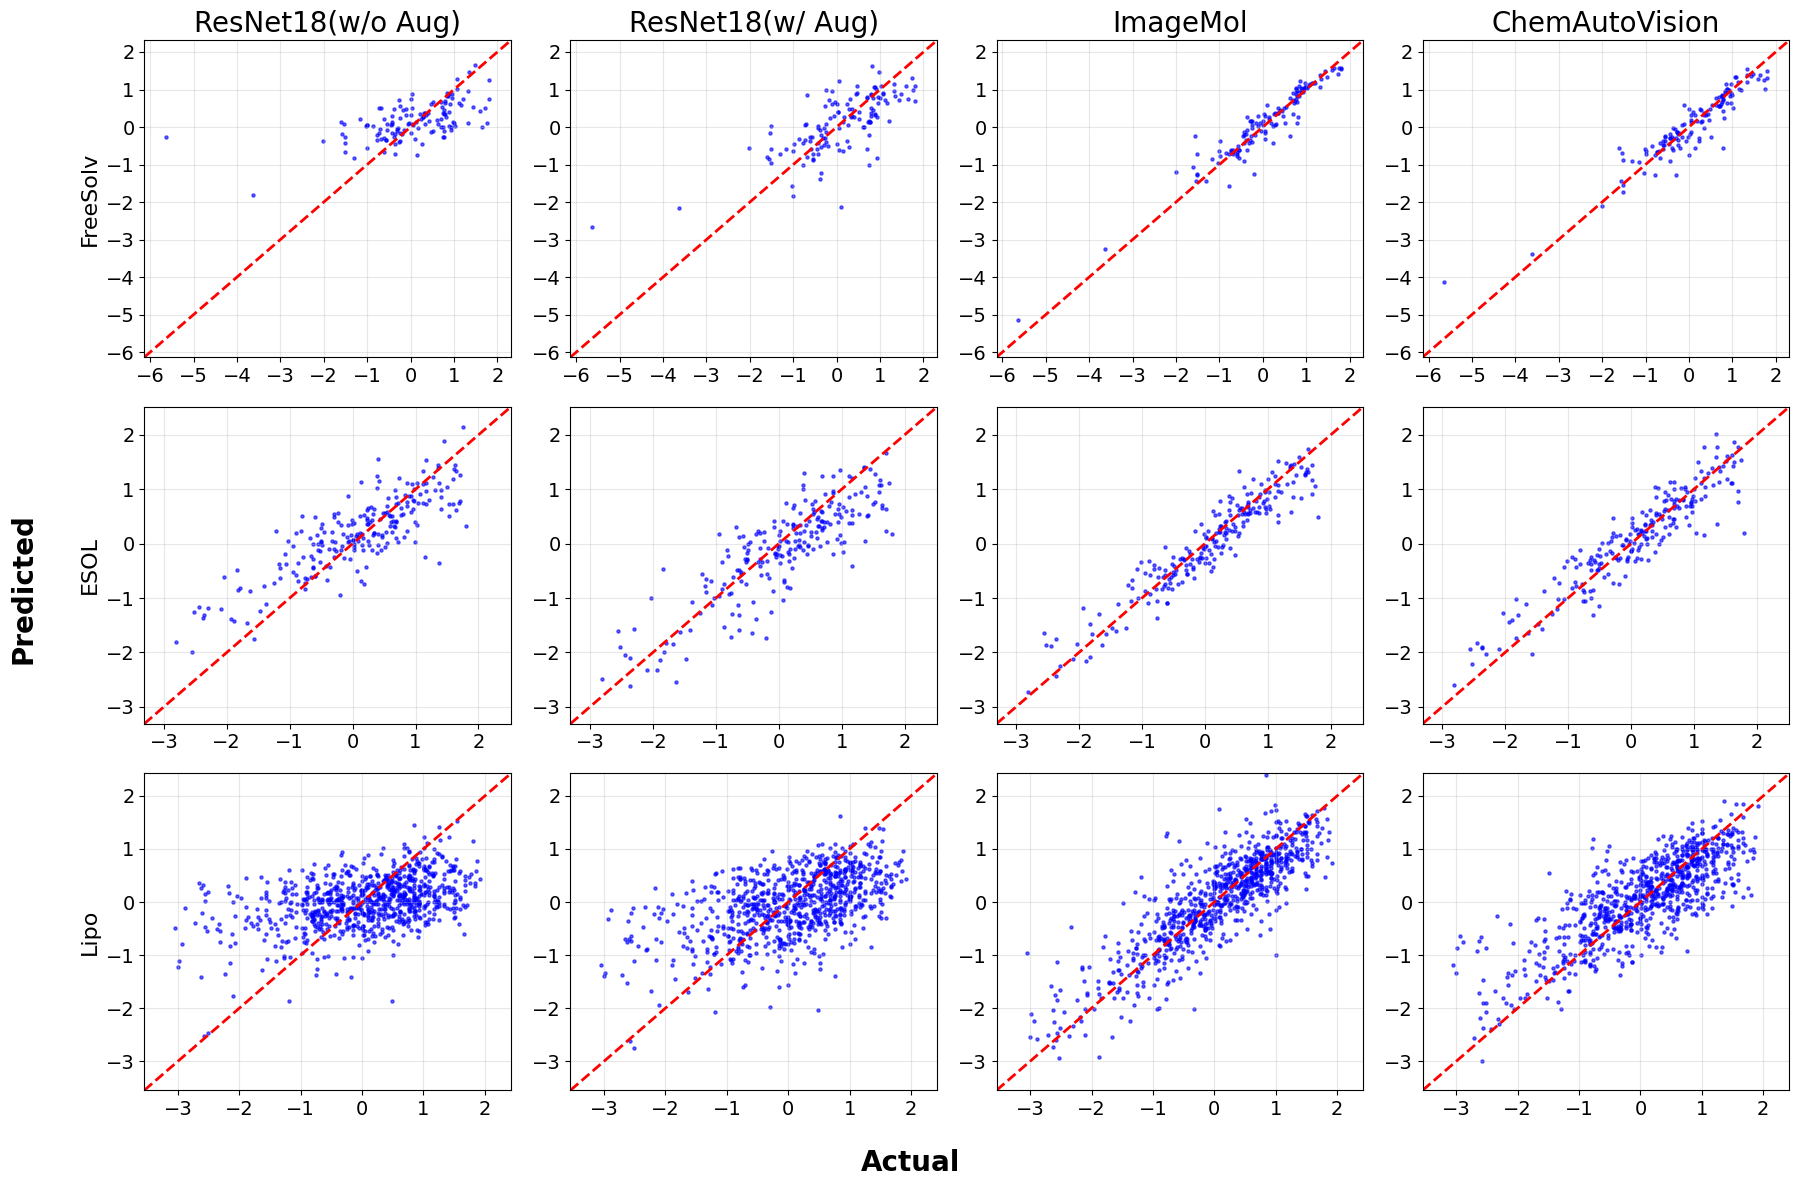

In [91]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for i, dataset_name in enumerate(datasets.keys()):
    df_ak = datasets[dataset_name]["ChemAutoVision"]
    range_max = max(df_ak["y_test"].max(), df_ak["y_preds"].max())+0.5
    range_min = min(df_ak["y_test"].min(), df_ak["y_preds"].min())-0.5
    
    for j, model_key in enumerate(models):
        ax = axes[i, j]
        
        # データの取得
        if dataset_name in datasets and model_key in datasets[dataset_name]:
            df = datasets[dataset_name][model_key]
            
            if df is not None and not df.empty:
                # 散布図を描画
                display_name = model_display_names[j]  # 表示用の名前を使用
                plot_actual_predicted(
                    df, 
                    ax=ax, 
                    title=f'{display_name}' if i == 0 else '',  # 最上段のみタイトル表示
                    min_val=range_min, 
                    max_val=range_max
                )
                if i == 0:
                    ax.set_title(display_name)
                
            else:
                # データが空の場合
                ax.text(0.5, 0.5, 'Empty Data', ha='center', va='center', transform=ax.transAxes)
                display_name = model_display_names[j]
                ax.set_title(f'{display_name}' if i == 0 else '')
                    
        else:
            # データがない場合は空のプロットを表示
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
            display_name = model_display_names[j]
            ax.set_title(f'{display_name}' if i == 0 else '')
        
        if j == 0:
            ax.set_ylabel(f'{dataset_name}')
        else:
            ax.set_ylabel(None)

        ax.tick_params(axis='both')

fig.supxlabel('Actual', fontsize=supxlabel_fontsize, fontweight='bold')
fig.supylabel('Predicted', fontsize=supylabel_fontsize, fontweight='bold', x=-0.0001)
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


# Metricsを棒グラフで描画

## regression

In [92]:
ak_freesolv_result = get_row_with_id(df_reg_ak, ak_freesolv_run_id)
resnet_nodaug_freesolv_result = get_row_with_id(df_reg_ak, resnet_nodaug_freesolv_run_id)
resnet_daug_freesolv_result = get_row_with_id(df_reg_ak, resnet_daug_freesolv_run_id)
imagemol_freesolv_result = get_row_with_id(df_reg, imgmol_freesolv_run_id)

ak_lipo_result = get_row_with_id(df_reg_ak, ak_lipo_run_id)
resnet_nodaug_lipo_result = get_row_with_id(df_reg_ak, resnet_nodaug_lipo_run_id)
resnet_daug_lipo_result = get_row_with_id(df_reg_ak, resnet_daug_lipo_run_id)
imagemol_lipo_result = get_row_with_id(df_reg, imgmol_lipo_run_id)

ak_dalaney_result = get_row_with_id(df_reg_ak, ak_dalaney_run_id)
resnet_nodaug_dalaney_result = get_row_with_id(df_reg_ak, resnet_nodaug_dalaney_run_id)
resnet_daug_dalaney_result = get_row_with_id(df_reg_ak, resnet_daug_dalaney_run_id)
imagemol_dalaney_result = get_row_with_id(df_reg, imgmol_dalaney_run_id)


In [93]:
data = {
    'FreeSolv': [
        extract_metric_score(resnet_nodaug_freesolv_result, "r2"),
        extract_metric_score(resnet_daug_freesolv_result, "r2"),
        extract_metric_score(imagemol_freesolv_result, "r2"),
        extract_metric_score(ak_freesolv_result, "r2"),
    ],
    'ESOL': [
        extract_metric_score(resnet_nodaug_dalaney_result, "r2"),
        extract_metric_score(resnet_daug_dalaney_result, "r2"),
        extract_metric_score(imagemol_dalaney_result, "r2"),
        extract_metric_score(ak_dalaney_result, "r2"),
    ],
    'Lipo': [
        extract_metric_score(resnet_nodaug_lipo_result, "r2"),
        extract_metric_score(resnet_daug_lipo_result, "r2"),
        extract_metric_score(imagemol_lipo_result, "r2"),
        extract_metric_score(ak_lipo_result, "r2"),
    ]
}

models = ['ResNet18(w/o Aug)', 'ResNet18(w/ Aug)', 'ImageMol','ChemAutoVision']
colors = ['#9E9E9E', '#4D4D4D', '#4C72B0', '#E24A33']

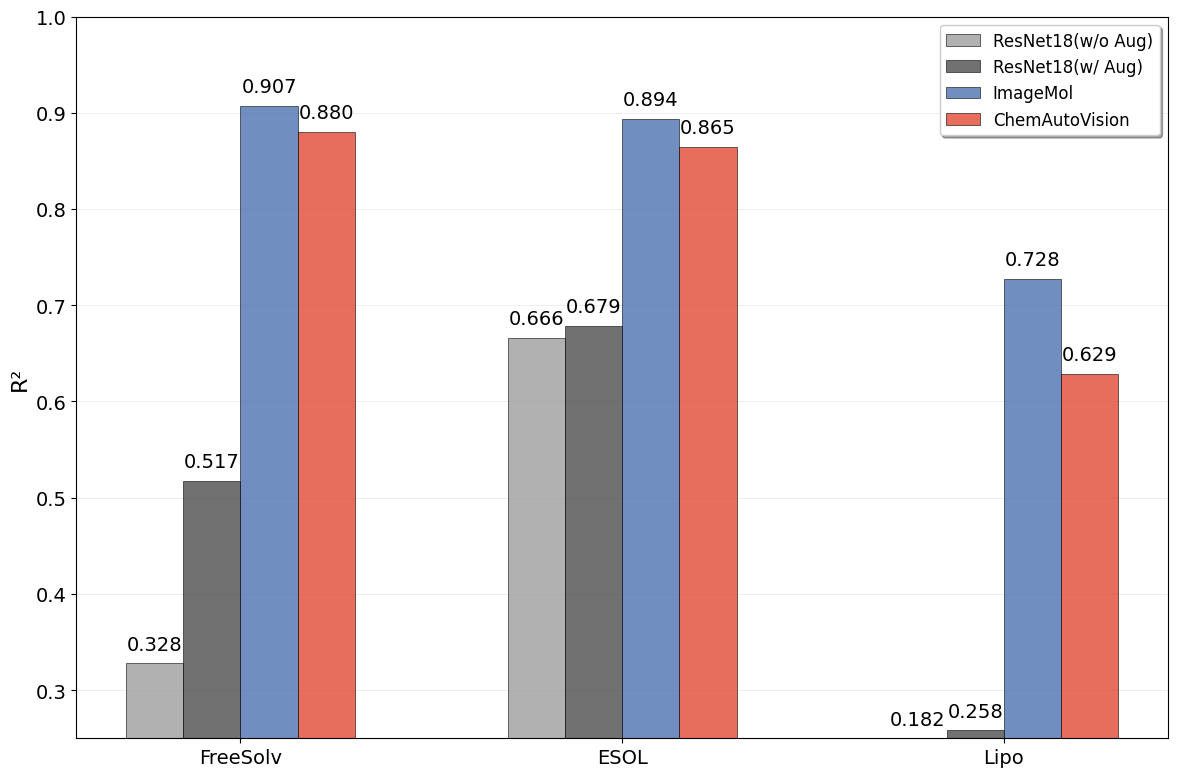

In [94]:
# グラフの設定
fig, ax = plt.subplots(figsize=(12, 8))

# バーの幅と位置
datasets = list(data.keys())
x = np.arange(len(datasets))
width = 0.15
ax.set_ylim(0.25, 1.0)

ymin, ymax = ax.get_ylim()


# 各モデルのバーを描画
for i, model in enumerate(models):
    values = [data[dataset][i] for dataset in datasets]
    
    for j, value in enumerate(values):
        xpos = x[j] + i * width - 2 * width
        value = float(value)

        bar = ax.bar(
            xpos, value, width,
            label=model if j == 0 else "",
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.8
        )

        y_text = max(value + 0.01, ymin + 0.01)

        ax.text(
            xpos,
            y_text,
            f'{value:.3f}',
            ha='center',
            va='bottom',
        )

# グラフの装飾
ax.set_ylabel('R²')
ax.set_xticks(x - width / 2)
ax.set_xticklabels(datasets)

# Y軸の範囲設定（画像に合わせて調整）
ax.set_yticks(np.arange(0.3, 1.001, 0.1))
ax.tick_params(axis='y')

ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# 凡例の設定
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# グリッドの追加
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# レイアウト調整
plt.tight_layout()
plt.show()

In [95]:
rmse_data = {
    'FreeSolv': [
        extract_metric_score(resnet_nodaug_freesolv_result, "rmse"),
        extract_metric_score(resnet_daug_freesolv_result, "rmse"),
        extract_metric_score(imagemol_freesolv_result, "rmse"),
        extract_metric_score(ak_freesolv_result, "rmse"),      # autokeras
    ],
    'ESOL': [
        extract_metric_score(resnet_nodaug_dalaney_result, "rmse"),
        extract_metric_score(resnet_daug_dalaney_result, "rmse"),
        extract_metric_score(imagemol_dalaney_result, "rmse"),
        extract_metric_score(ak_dalaney_result, "rmse"),
    ],
    'Lipo': [
        extract_metric_score(resnet_nodaug_lipo_result, "rmse"),
        extract_metric_score(resnet_daug_lipo_result, "rmse"),
        extract_metric_score(imagemol_lipo_result, "rmse"),
        extract_metric_score(ak_lipo_result, "rmse"),
    ]
}

models = ['ResNet18(w/o Aug)', 'ResNet18(w/ Aug)', 'ImageMol','ChemAutoVision']
colors = ['#9E9E9E', '#4D4D4D', '#4C72B0', '#E24A33']

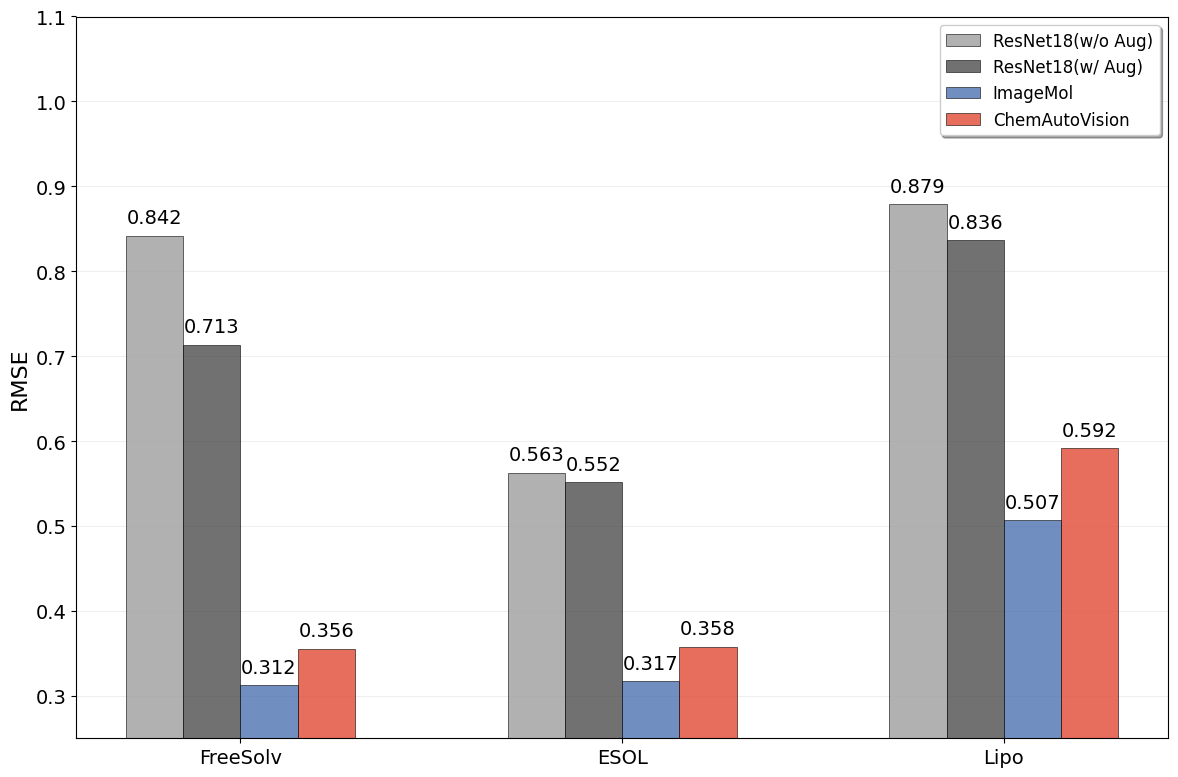

In [96]:
# グラフの設定
fig, ax = plt.subplots(figsize=(12, 8))

# バーの幅と位置
datasets = list(rmse_data.keys())
x = np.arange(len(datasets))
width = 0.15
ax.set_ylim(0.25, 1.5)

ymin, ymax = ax.get_ylim()


# 各モデルのバーを描画
for i, model in enumerate(models):
    values = [rmse_data[dataset][i] for dataset in datasets]
    
    for j, value in enumerate(values):
        xpos = x[j] + i * width - 2 * width
        value = float(value)

        bar = ax.bar(
            xpos, value, width,
            label=model if j == 0 else "",
            color=colors[i],
            edgecolor='black',
            linewidth=0.5,
            alpha=0.8
        )

        y_text = max(value + 0.01, ymin + 0.01)

        ax.text(
            xpos,
            y_text,
            f'{value:.3f}',
            ha='center',
            va='bottom',
        )

# グラフの装飾
ax.set_ylabel('RMSE')
ax.set_xticks(x - width / 2)
ax.set_xticklabels(datasets)

# Y軸の範囲設定（画像に合わせて調整）
ax.set_yticks(np.arange(0.3, 1.101, 0.1))
ax.set_ylim(0.25, 1.1)
ax.tick_params(axis='y')

# 凡例の設定
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# グリッドの追加
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# レイアウト調整
plt.tight_layout()

plt.show()

## classification

In [97]:
ak_bbbp_run_id = get_best_run_id(df_cls_ak, "BBBP", "roc_auc", "max", "autokeras", is_daug=True)
resnet_no_daug_bbbp_run_id = get_best_run_id(df_cls_ak, "BBBP", "roc_auc", "max", "resnet18", is_daug=False)
resnet_daug_bbbp_run_id = get_best_run_id(df_cls_ak, "BBBP", "roc_auc", "max", "resnet18", is_daug=True)
imgmol_bbbp_run_id = get_best_run_id(df_cls, "BBBP", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)


ak_pgp_run_id = get_best_run_id(df_cls_ak, "P-gp", "roc_auc", "max", "autokeras", is_daug=True)
resnet_no_daug_pgp_run_id = get_best_run_id(df_cls_ak, "P-gp", "roc_auc", "max", "resnet18", is_daug=False)
resnet_daug_pgp_run_id = get_best_run_id(df_cls_ak, "P-gp", "roc_auc", "max", "resnet18", is_daug=True)
imgmol_pgp_run_id = get_best_run_id(df_cls, "P-gp", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

ak_cyp_run_id = get_best_run_id(df_cls_ak, "CYP3A4", "roc_auc", "max", "autokeras", is_daug=True)
resnet_no_daug_cyp_run_id = get_best_run_id(df_cls_ak, "CYP3A4", "roc_auc", "max", "resnet18", is_daug=False)
resnet_daug_cyp_run_id = get_best_run_id(df_cls_ak, "CYP3A4", "roc_auc", "max", "resnet18", is_daug=True)
imgmol_cyp_run_id = get_best_run_id(df_cls, "CYP3A4", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)

ak_herg_run_id = get_best_run_id(df_cls_ak, "hERG", "roc_auc", "max", "autokeras", is_daug=True)
resnet_no_daug_herg_run_id = get_best_run_id(df_cls_ak, "hERG", "roc_auc", "max", "resnet18", is_daug=False)
resnet_daug_herg_run_id = get_best_run_id(df_cls_ak, "hERG", "roc_auc", "max", "resnet18", is_daug=True)
imgmol_herg_run_id = get_best_run_id(df_cls, "hERG", "roc_auc", "max", "ImageMol", is_weighted_balanced=True)


model_name: autokeras
✅ 最適なRun ID: b27a1cc084bb4e86a9f33f8085f81e8e
   model_name: autokeras
   target: BBBP
   roc_auc: 0.8860412637008381
model_name: resnet18
✅ 最適なRun ID: 7d3fb7faa6214b1b980d9e2e7a62feb4
   model_name: resnet18
   target: BBBP
   roc_auc: 0.8520846765527617
model_name: resnet18
✅ 最適なRun ID: 97a7c67451044aafa8792c1f17d108a7
   model_name: resnet18
   target: BBBP
   roc_auc: 0.8666809943405689
model_name: ImageMol
✅ 最適なRun ID: df3aeb990f484bc5b29e13e9f862a78f
   model_name: ImageMol
   target: BBBP
   roc_auc: 0.9234723117701842
model_name: autokeras
✅ 最適なRun ID: 09f1665b9ff34511872d0f2e4c1594db
   model_name: autokeras
   target: P-gp
   roc_auc: 0.8402621305075292
model_name: resnet18
✅ 最適なRun ID: e18fb39e8e7144faa6ef21386b780b35
   model_name: resnet18
   target: P-gp
   roc_auc: 0.7091187953151145
model_name: resnet18
✅ 最適なRun ID: 17602121f1924b1194947a6ffd98dd05
   model_name: resnet18
   target: P-gp
   roc_auc: 0.7810708310094813
model_name: ImageMol
✅ 最適なRun 

/chemAutoVision/src/notebooks/visualize_utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model_name"] = df["model_name"].replace(["None", "nan", "NaN"], None)
/chemAutoVision/src/notebooks/visualize_utils.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[metric] = filtered_df[metric].astype(str).str.strip("'")
/chemAutoVision/src/notebooks/visualize_utils.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [98]:
ak_bbbp_result = get_row_with_id(df_cls, ak_bbbp_run_id)
resnet_no_daug_bbbp_result = get_row_with_id(df_cls, resnet_no_daug_bbbp_run_id)
resnet_daug_bbbp_result = get_row_with_id(df_cls, resnet_daug_bbbp_run_id)
imagemol_bbbp_result = get_row_with_id(df_cls, imgmol_bbbp_run_id)

ak_pgp_result = get_row_with_id(df_cls, ak_pgp_run_id)
resnet_no_daug_pgp_result = get_row_with_id(df_cls, resnet_no_daug_pgp_run_id)
resnet_daug_pgp_result = get_row_with_id(df_cls, resnet_daug_pgp_run_id)
imagemol_pgp_result = get_row_with_id(df_cls, imgmol_pgp_run_id)

ak_cyp_result = get_row_with_id(df_cls, ak_cyp_run_id)
resnet_no_daug_cyp_result = get_row_with_id(df_cls, resnet_no_daug_cyp_run_id)
resnet_daug_cyp_result = get_row_with_id(df_cls, resnet_daug_cyp_run_id)
imagemol_cyp_result = get_row_with_id(df_cls, imgmol_cyp_run_id)

ak_herg_result = get_row_with_id(df_cls, ak_herg_run_id)
resnet_no_daug_herg_result = get_row_with_id(df_cls, resnet_no_daug_herg_run_id)
resnet_daug_herg_result = get_row_with_id(df_cls, resnet_daug_herg_run_id)
imagemol_herg_result = get_row_with_id(df_cls, imgmol_herg_run_id)

In [99]:
data_cls = {
    'BBBP': [
        extract_metric_score(resnet_no_daug_bbbp_result, "roc_auc"),
        extract_metric_score(resnet_daug_bbbp_result, "roc_auc"),
        extract_metric_score(imagemol_bbbp_result, "roc_auc"), 
        extract_metric_score(ak_bbbp_result, "roc_auc"),
    ],
    'P-gp': [
        extract_metric_score(resnet_no_daug_pgp_result, "roc_auc"),
        extract_metric_score(resnet_daug_pgp_result, "roc_auc"),
        extract_metric_score(imagemol_pgp_result, "roc_auc"),
        extract_metric_score(ak_pgp_result, "roc_auc"),
    ],
    'CYP3A4': [
        extract_metric_score(resnet_no_daug_cyp_result, "roc_auc"),
        extract_metric_score(resnet_daug_cyp_result, "roc_auc"),
        extract_metric_score(imagemol_cyp_result, "roc_auc"),
        extract_metric_score(ak_cyp_result, "roc_auc"),
    ],
    'hERG': [
        extract_metric_score(resnet_no_daug_herg_result, "roc_auc"),
        extract_metric_score(resnet_daug_herg_result, "roc_auc"),
        extract_metric_score(imagemol_herg_result, "roc_auc"),
        extract_metric_score(ak_herg_result, "roc_auc"),
    ]
}

models = ['ResNet18(w/o Aug)', 'ResNet18(w/ Aug)', 'ImageMol','ChemAutoVision']
colors = ['#9E9E9E', '#4D4D4D', '#4C72B0', '#E24A33']

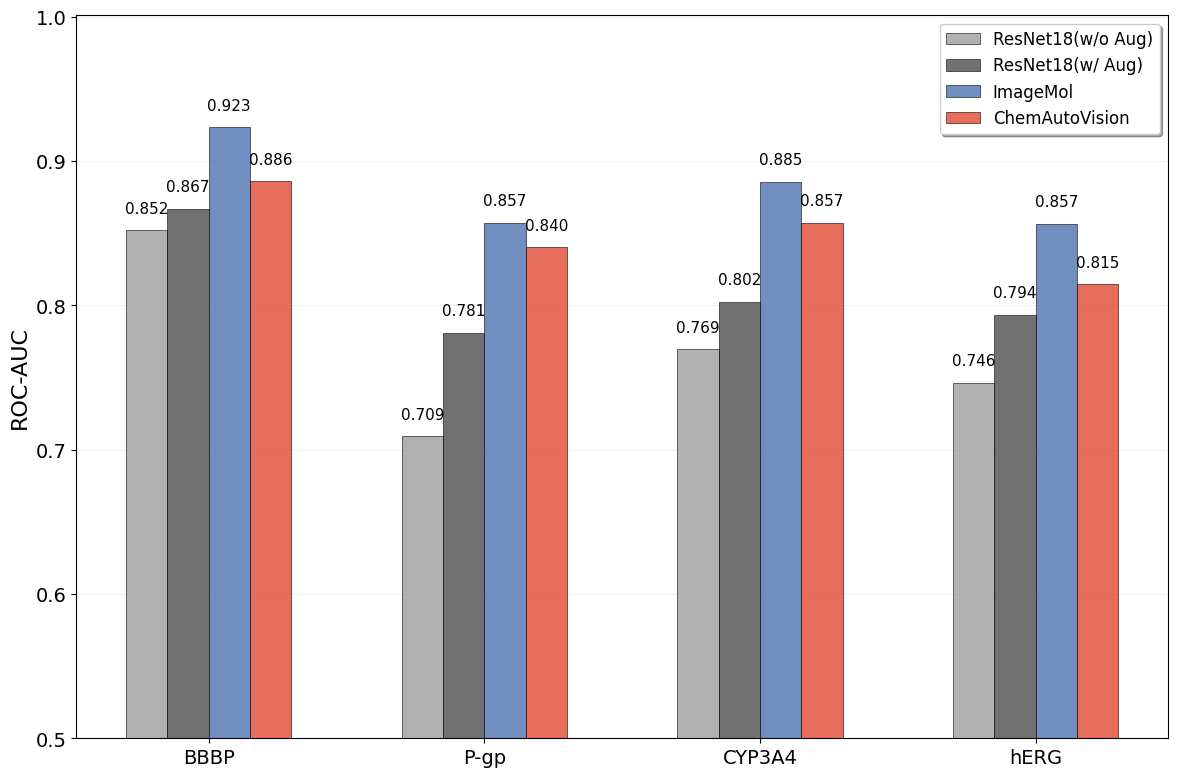

In [100]:
fig, ax = plt.subplots(figsize=(12, 8))

# バーの幅と位置
x = np.arange(len(data_cls))
width = 0.15

# 各モデルのバーを描画
for i, model in enumerate(models):
    values = [data_cls[dataset][i] for dataset in data_cls.keys()]
    bars = ax.bar(x + i * width - 2 * width, values, width, label=model, color=colors[i], 
                  edgecolor='black', linewidth=0.5, alpha=0.8)
    
    # 各棒の上に値を表示
    for j, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=11, rotation=0)

# グラフの装飾
ax.set_ylabel('ROC-AUC')
ax.set_xticks(x - width / 2)
ax.set_xticklabels(data_cls)

# Y軸の範囲設定
ax.set_ylim(0.5, 1.001)
ax.set_yticks(np.arange(0.5, 1.0001, 0.1))
ax.tick_params(axis='y')

# 凡例の設定（グラフ枠内に配置）
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# グリッドの追加
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# レイアウト調整
plt.tight_layout()

plt.show()

## 混合行列

In [101]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)

In [102]:
def confusion_matrix_fixed_threshold(
    y_true,
    y_pred_proba,
    threshold=0.5,
    labels=(0, 1),
):
    """
    y_true        : array-like, shape (n_samples,)
    y_pred_proba  : predicted probability for positive class
    threshold     : classification threshold
    """

    y_pred = (y_pred_proba > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    mcc = matthews_corrcoef(y_true, y_pred)

    return cm, mcc

In [103]:
def plot_confusion_matrix(
    cm,
    ax,
    title="Confusion Matrix",
    class_names=("0", "1"),
    show_xlabel=False,
    show_ylabel=False,
    label_size=20,
    tick_size=20,
    value_size=20,
    title_size=20,
):
    cm = np.array(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=tick_size)
    ax.set_yticklabels(class_names, fontsize=tick_size)

    # ラベル制御
    if show_xlabel:
        ax.set_xlabel("Prediction", fontsize=label_size)
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel("Ground truth", fontsize=label_size)
    else:
        ax.set_ylabel("")

    ax.set_title(title, fontsize=title_size)

    for text in ax.texts:
        text.set_fontsize(value_size)


In [104]:
def parse_array_block_to_1d_floats(block: str) -> np.ndarray:
    """
    "array([[0.], [1.], ...])" の中身から数値だけ抜き出して 1D float にする
    """
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", block)
    return np.array([float(x) for x in nums], dtype=float)

def parse_tensor_block_to_1d_floats(block: str) -> np.ndarray:
    """
    "tensor([[3.36e-03], ...], dtype=float32)" の中身から数値だけ抜き出して 1D float にする
    """
    # dtype=float32 などを含むので数値だけ抽出
    nums = re.findall(r"[-+]?\d*\.\d+(?:e[-+]?\d+)?|[-+]?\d+(?:e[-+]?\d+)?", block, flags=re.IGNORECASE)
    return np.array([float(x) for x in nums], dtype=float)

def row_to_df_no_eval(row_str: str) -> pd.DataFrame:
    """
    "{'y_true': array(...), 'y_pred': array(...), 'y_pro': tensor(...)}" 形式の文字列から
    y_true, y_pred, y_pro を DataFrame に変換する（evalなし）
    """
    if not isinstance(row_str, str):
        # もし dict で入っている場合にも対応
        import numpy as np
        d = row_str
        y_true = np.asarray(d["y_true"]).reshape(-1).astype(int)
        y_pred = np.asarray(d["y_pred"]).reshape(-1).astype(int)
        y_pro  = np.asarray(d["y_pro"]).reshape(-1).astype(float)
        return pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "y_pro": y_pro})

    # y_true ブロック抽出
    m_true = re.search(r"'y_true'\s*:\s*array\((\[[\s\S]*?\])\)", row_str)
    if not m_true:
        raise ValueError("Could not find y_true array(...) block.")
    y_true = parse_array_block_to_1d_floats(m_true.group(1)).astype(int)

    # y_pred ブロック抽出
    m_pred = re.search(r"'y_pred'\s*:\s*array\((\[[\s\S]*?\])\s*,\s*dtype=float32\)", row_str)
    if not m_pred:
        # dtypeの表記ゆれ用にフォールバック
        m_pred = re.search(r"'y_pred'\s*:\s*array\((\[[\s\S]*?\])\)", row_str)
    if not m_pred:
        raise ValueError("Could not find y_pred array(...) block.")
    y_pred = parse_array_block_to_1d_floats(m_pred.group(1)).astype(int)

    # y_pro ブロック抽出（tensor部分）
    m_pro = re.search(r"'y_pro'\s*:\s*tensor\((\[[\s\S]*?\])\s*\)", row_str)
    if not m_pro:
        raise ValueError("Could not find y_pro tensor(...) block.")
    y_pro = parse_tensor_block_to_1d_floats(m_pro.group(1))

    # 長さチェック
    n = len(y_true)
    if len(y_pred) != n or len(y_pro) != n:
        raise ValueError(f"Length mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}, y_pro={len(y_pro)}")

    return pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "y_pro": y_pro})



In [105]:
results_resnet_nodaug_bbbp = pd.read_csv(resnet_no_daug_bbbp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_resnet_daug_bbbp = pd.read_csv(resnet_daug_bbbp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_imagemol_bbbp = pd.read_csv(imagemol_bbbp_result.result_csv_path.iloc[0].replace("./results", "../../results"))
results_ak_bbbp = pd.read_csv(ak_bbbp_result.result_csv_path.iloc[0].replace("../results", "../../results"))

results_resnet_nodaug_pgp = pd.read_csv(resnet_no_daug_pgp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_resnet_daug_pgp = pd.read_csv(resnet_daug_pgp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_imagemol_pgp = pd.read_csv(imagemol_pgp_result.result_csv_path.iloc[0].replace("./results", "../../results"))
results_ak_pgp = pd.read_csv(ak_pgp_result.result_csv_path.iloc[0].replace("../results", "../../results"))

results_resnet_nodaug_herg = pd.read_csv(resnet_no_daug_herg_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_resnet_daug_herg = pd.read_csv(resnet_daug_herg_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_imagemol_herg = pd.read_csv(imagemol_herg_result.result_csv_path.iloc[0].replace("./results", "../../results"))
results_ak_herg = pd.read_csv(ak_herg_result.result_csv_path.iloc[0].replace("../results", "../../results"))

results_resnet_nodaug_cyp = pd.read_csv(resnet_no_daug_cyp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_resnet_daug_cyp = pd.read_csv(resnet_daug_cyp_result.result_csv_path.iloc[0].replace("../results", "../../results"))
results_imagemol_cyp = pd.read_csv(imagemol_cyp_result.result_csv_path.iloc[0].replace("./results", "../../results"))
results_ak_cyp = pd.read_csv(ak_cyp_result.result_csv_path.iloc[0].replace("../results", "../../results"))

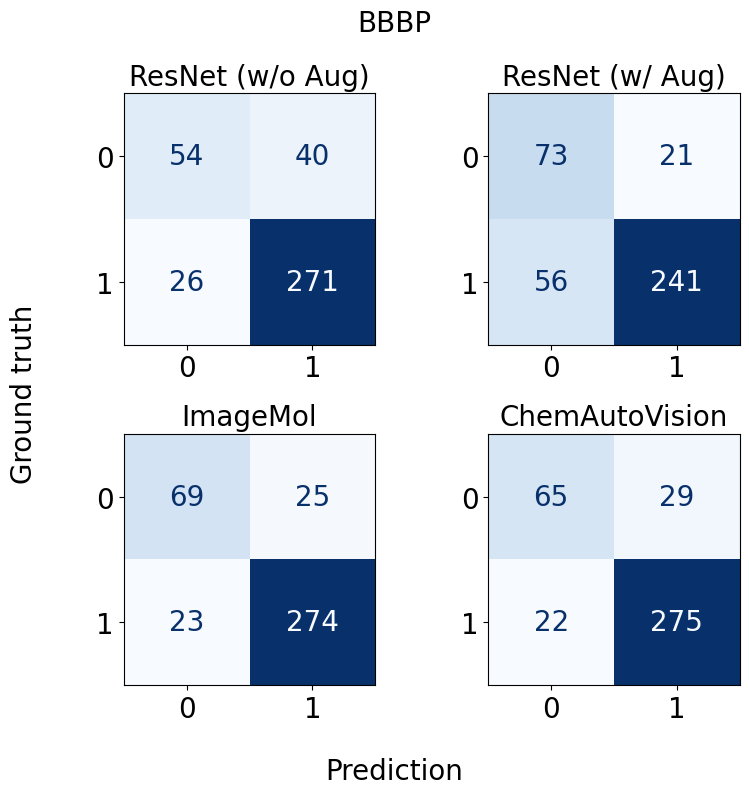

In [106]:
cm_resnet_nodaug_bbbp, _ = confusion_matrix_fixed_threshold(results_resnet_nodaug_bbbp.y_test, results_resnet_nodaug_bbbp.y_preds)
cm_resnet_daug_bbbp, _ = confusion_matrix_fixed_threshold(results_resnet_daug_bbbp.y_test, results_resnet_daug_bbbp.y_preds)
cm_imagemol_daug_bbbp, _ = confusion_matrix_fixed_threshold(results_imagemol_bbbp.y_test, results_imagemol_bbbp.y_preds)
cm_ak_bbbp, _ = confusion_matrix_fixed_threshold(results_ak_bbbp.y_test, results_ak_bbbp.y_preds)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plot_confusion_matrix(cm_resnet_nodaug_bbbp, axes[0,0], "ResNet (w/o Aug)")
plot_confusion_matrix(cm_resnet_daug_bbbp, axes[0,1], "ResNet (w/ Aug)")
plot_confusion_matrix(cm_imagemol_daug_bbbp, axes[1,0], "ImageMol")
plot_confusion_matrix(cm_ak_bbbp, axes[1,1], "ChemAutoVision")

fig.suptitle("BBBP", fontsize=supxlabel_fontsize)
fig.supxlabel("Prediction", fontsize=supxlabel_fontsize)
fig.supylabel("Ground truth", fontsize=supylabel_fontsize)

plt.tight_layout()
plt.savefig("confusion_matrix_bbbp.png", dpi=150, bbox_inches="tight")
plt.show()

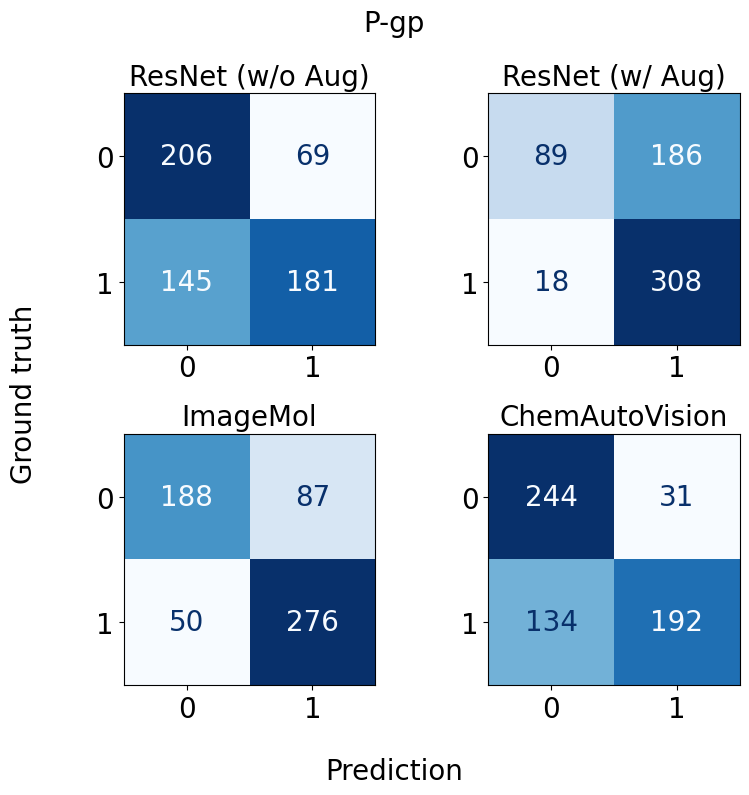

In [107]:
cm_resnet_nodaug_pgp, _ = confusion_matrix_fixed_threshold(results_resnet_nodaug_pgp.y_test, results_resnet_nodaug_pgp.y_preds)
cm_resnet_daug_pgp, _ = confusion_matrix_fixed_threshold(results_resnet_daug_pgp.y_test, results_resnet_daug_pgp.y_preds)
cm_imagemol_daug_pgp, _ = confusion_matrix_fixed_threshold(results_imagemol_pgp.y_test, results_imagemol_pgp.y_preds)
cm_ak_pgp, _ = confusion_matrix_fixed_threshold(results_ak_pgp.y_test, results_ak_pgp.y_preds)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plot_confusion_matrix(cm_resnet_nodaug_pgp, axes[0,0], "ResNet (w/o Aug)")
plot_confusion_matrix(cm_resnet_daug_pgp, axes[0,1], "ResNet (w/ Aug)")
plot_confusion_matrix(cm_imagemol_daug_pgp, axes[1,0], "ImageMol")
plot_confusion_matrix(cm_ak_pgp, axes[1,1], "ChemAutoVision")

fig.suptitle("P-gp", fontsize=supxlabel_fontsize)
fig.supxlabel("Prediction", fontsize=supxlabel_fontsize)
fig.supylabel("Ground truth", fontsize=supylabel_fontsize)

plt.tight_layout()
plt.savefig("confusion_matrix_pgp.png", dpi=150, bbox_inches="tight")
plt.show()

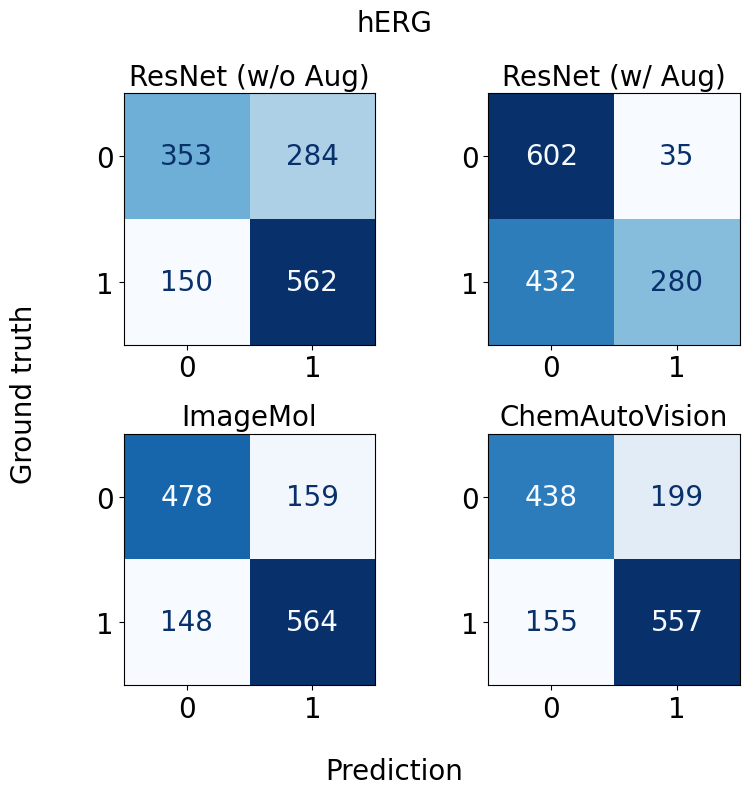

In [108]:
cm_resnet_nodaug_herg, _ = confusion_matrix_fixed_threshold(
    results_resnet_nodaug_herg.y_test,
    results_resnet_nodaug_herg.y_preds
)

cm_resnet_daug_herg, _ = confusion_matrix_fixed_threshold(
    results_resnet_daug_herg.y_test,
    results_resnet_daug_herg.y_preds
)

cm_imagemol_daug_herg, _ = confusion_matrix_fixed_threshold(
    results_imagemol_herg.y_test,
    results_imagemol_herg.y_preds
)

cm_ak_herg, _ = confusion_matrix_fixed_threshold(
    results_ak_herg.y_test,
    results_ak_herg.y_preds
)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plot_confusion_matrix(cm_resnet_nodaug_herg, axes[0,0], "ResNet (w/o Aug)")
plot_confusion_matrix(cm_resnet_daug_herg, axes[0,1], "ResNet (w/ Aug)")
plot_confusion_matrix(cm_imagemol_daug_herg, axes[1,0], "ImageMol")
plot_confusion_matrix(cm_ak_herg, axes[1,1], "ChemAutoVision")

fig.suptitle("hERG", fontsize=supxlabel_fontsize)
fig.supxlabel("Prediction", fontsize=supxlabel_fontsize)
fig.supylabel("Ground truth", fontsize=supylabel_fontsize)

plt.tight_layout()
plt.savefig("confusion_matrix_herg.png", dpi=150, bbox_inches="tight")
plt.show()


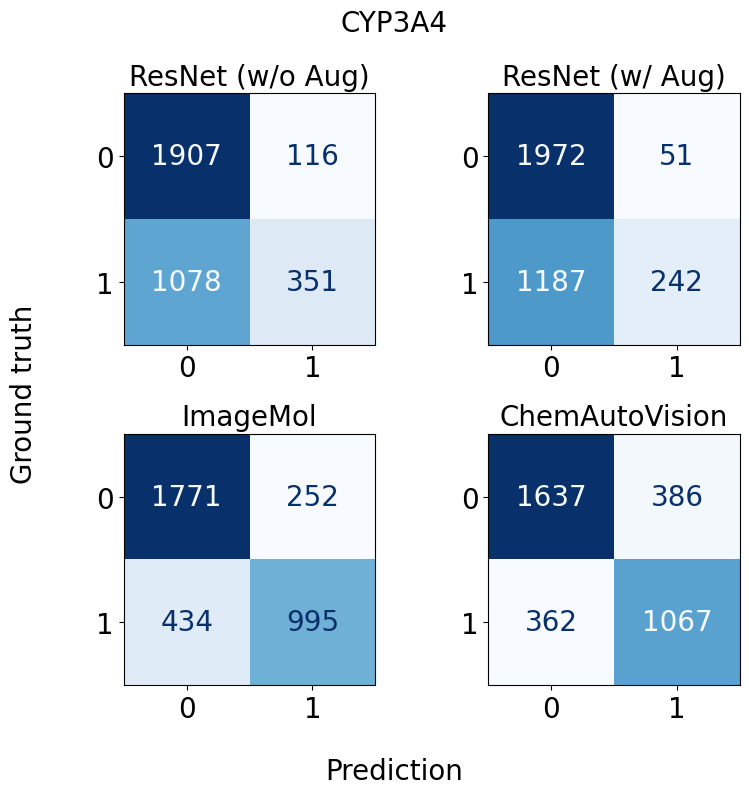

In [109]:
# --- 混合行列作成 ---
cm_resnet_nodaug_cyp, _ = confusion_matrix_fixed_threshold(
    results_resnet_nodaug_cyp.y_test,
    results_resnet_nodaug_cyp.y_preds
)

cm_resnet_daug_cyp, _ = confusion_matrix_fixed_threshold(
    results_resnet_daug_cyp.y_test,
    results_resnet_daug_cyp.y_preds
)

cm_imagemol_daug_cyp, _ = confusion_matrix_fixed_threshold(
    results_imagemol_cyp.y_test,
    results_imagemol_cyp.y_preds
)

cm_ak_cyp, _ = confusion_matrix_fixed_threshold(
    results_ak_cyp.y_test,
    results_ak_cyp.y_preds
)

# --- 描画 ---
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plot_confusion_matrix(cm_resnet_nodaug_cyp, axes[0,0], "ResNet (w/o Aug)")
plot_confusion_matrix(cm_resnet_daug_cyp, axes[0,1], "ResNet (w/ Aug)")
plot_confusion_matrix(cm_imagemol_daug_cyp, axes[1,0], "ImageMol")
plot_confusion_matrix(cm_ak_cyp, axes[1,1], "ChemAutoVision")

fig.suptitle("CYP3A4", fontsize=supxlabel_fontsize)
fig.supxlabel("Prediction", fontsize=supxlabel_fontsize)
fig.supylabel("Ground truth", fontsize=supylabel_fontsize)

plt.tight_layout()
plt.savefig("confusion_matrix_cyp3a4.png", dpi=150, bbox_inches="tight")
plt.show()

# Histgram

In [110]:
from rdkit import Chem
from rdkit.Chem import BRICS, Descriptors, Draw
from collections import Counter

In [111]:
def decompose_with_brics(smiles):
    """
    BRICSを使ってSMILESを分解し、フラグメントのリストを返す
    
    Args:
        smiles (str): SMILES文字列
    
    Returns:
        list: BRICSで分解されたフラグメントのSMILESリスト、エラーの場合は空リスト
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise Error("invalid SMILES is input")
        
        # BRICSで分解
        fragments = BRICS.BRICSDecompose(mol)
        
        if not fragments:
            # BRICS分解できない場合は元の分子を返す
            return [smiles]
        
        # 有効なフラグメントのみをフィルタリング
        valid_fragments = []
        for frag_smiles in fragments:
            try:
                # BRICSの結果には[*]のようなダミー原子が含まれるが、
                # SMILESとしては有効なので、そのまま保持
                # 分子オブジェクトに変換できるかチェック
                clean_smiles = frag_smiles.replace('[*]', '[H]')
                frag_mol = Chem.MolFromSmiles(clean_smiles)
                
                if frag_mol is not None:
                    valid_fragments.append(frag_smiles)
            except:
                continue
        
        return valid_fragments if valid_fragments else [smiles]
        
    except Exception as e:
        raise Error(f"Error processing {smiles}: {e}")

In [112]:
def analyze_all_fragments_diversity(df, smiles_column='smiles', figsize=(12, 8), 
                                   visualize_structures=True, show_diversity_analysis=True, n_top=20):
    """
    DataFrameからすべてのBRICSフラグメントを抽出して多様性分析
    
    Args:
        df (pd.DataFrame): SMILESを含むDataFrame
        smiles_column (str): SMILES列の名前
        figsize (tuple): 図のサイズ
        visualize_structures (bool): fragment構造を可視化するかどうか
        show_diversity_analysis (bool): 多様性分析を表示するかどうか
    
    Returns:
        tuple: (fragment_df, scaffold_counts)
    """
    print("全BRICSフラグメントの抽出を開始します...")
    
    # 各分子からすべてのフラグメントを抽出
    all_fragments = []
    molecule_ids = []
    
    for idx, smiles in enumerate(df[smiles_column]):
        fragments = decompose_with_brics(smiles)
        for fragment in fragments:
            all_fragments.append(fragment)
            molecule_ids.append(idx)
    
    # フラグメントのDataFrameを作成
    fragment_df = pd.DataFrame({
        'molecule_id': molecule_ids,
        'fragment': all_fragments
    })
    
    # 元のDataFrameの情報をマージ
    fragment_df = fragment_df.merge(df.reset_index(drop=True).reset_index().rename(columns={'index': 'molecule_id'}), 
                                   on='molecule_id', how='left')
    
    # Noneの値を除去
    fragment_df_clean = fragment_df.dropna(subset=['fragment'])
    
    print(f"総分子数: {len(df)}")
    print(f"総フラグメント数: {len(fragment_df_clean)}")
    print(f"分子あたり平均フラグメント数: {len(fragment_df_clean)/len(df):.2f}")
    
    # フラグメントの頻度を計算
    fragment_counts = Counter(fragment_df_clean['fragment'])
    
    print(f"ユニークなフラグメント数: {len(fragment_counts)}")
    
    # ヒストグラム用のデータを準備
    # 全fragmentの頻度分布を表示
    frequency_values = list(fragment_counts.values())
    
    # 図を作成
    plt.figure(figsize=figsize)
    
    # ヒストグラムを描画
    n, bins, patches = plt.hist(frequency_values, bins='auto', alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    
    plt.xlabel('Fragment Frequency')
    plt.ylabel('Number of Fragments')
    plt.title(f'Distribution of BRICS Fragment Frequencies (All Fragments)\n(Total: {len(fragment_counts)} unique fragments)')
    plt.grid(axis='y', alpha=0.3)
    
    # 統計情報をプロット上に表示
    mean_freq = np.mean(frequency_values)
    median_freq = np.median(frequency_values)
    plt.axvline(mean_freq, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_freq:.2f}')
    plt.axvline(median_freq, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_freq:.2f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 追加でTop fragmentのバープロットも表示
    top_n = min(n_top, len(fragment_counts))
    top_fragments = fragment_counts.most_common(top_n)
    
    if len(fragment_counts) > 1:
        fragments, counts = zip(*top_fragments)
        
        plt.figure(figsize=(figsize[0], figsize[1]*0.6))
        bars = plt.bar(range(len(fragments)), counts, alpha=0.7, color='lightcoral', edgecolor='darkred')
        
        plt.xticks(range(len(fragments)), 
                   [f"{i+1}" for i in range(len(fragments))], 
                   rotation=0)
        
        plt.xlabel('Fragment Rank')
        plt.ylabel('Frequency')
        plt.title(f'Top {top_n} Most Frequent BRICS Fragments (All Fragments)')
        plt.grid(axis='y', alpha=0.3)
        
        # バーの上に頻度を表示
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    # 統計情報を表示
    print("\n=== Fragment分布統計 ===")
    print(f"ユニークなフラグメント数: {len(fragment_counts)}")
    print(f"頻度の分布:")
    print(f"  平均: {np.mean(list(fragment_counts.values())):.2f}")
    print(f"  中央値: {np.median(list(fragment_counts.values())):.2f}")
    print(f"  標準偏差: {np.std(list(fragment_counts.values())):.2f}")
    print(f"  最大頻度: {max(fragment_counts.values())}")
    print(f"  最小頻度: {min(fragment_counts.values())}")
    
    # 頻度1のフラグメント数
    unique_fragments = sum(1 for count in fragment_counts.values() if count == 1)
    print(f"  頻度1のフラグメント数: {unique_fragments} ({unique_fragments/len(fragment_counts)*100:.1f}%)")
    
    top_fragments = fragment_counts.most_common(min(20, len(fragment_counts)))
    
    # Top fragmentの詳細を表示
    print(f"\n=== Top {min(10, len(top_fragments))} Fragments ===")
    for i, (fragment, count) in enumerate(top_fragments[:10]):
        print(f"{i+1:2d}. {fragment} (頻度: {count})")
    
    # 構造の可視化
    if visualize_structures:
        print(f"\n=== Top {min(n_top, len(top_fragments))} Fragment Structures ===")
        visualize_scaffold_structures(fragment_counts, top_n=min(n_top, len(fragment_counts)))
    
    # 多様性分析
    if show_diversity_analysis:
        print(f"\n=== Fragment Diversity Analysis ===")
        diversity_metrics = plot_diversity_visualizations(fragment_counts, len(fragment_df_clean))
        
        print(f"\n=== Fragment Diversity Metrics ===")
        print(f"Fragment Diversity Ratio: {diversity_metrics['diversity_ratio']:.3f}")
        print(f"Shannon Entropy: {diversity_metrics['shannon_entropy']:.3f}")
        print(f"Simpson Diversity Index: {diversity_metrics['simpson_index']:.3f}")
        print(f"Gini Coefficient: {diversity_metrics['gini_coefficient']:.3f}")
        print(f"Singleton Ratio: {diversity_metrics['singleton_ratio']:.3f}")
        print(f"Top 10% Concentration: {diversity_metrics['top_10_percent_concentration']:.3f}")
        
        # 多様性の解釈
        print(f"\n=== Fragment Diversity Interpretation ===")
        if diversity_metrics['diversity_ratio'] > 0.7:
            print("✓ Very high fragment diversity (>70% unique fragments)")
        elif diversity_metrics['diversity_ratio'] > 0.5:
            print("✓ High fragment diversity (>50% unique fragments)")
        else:
            print("• Moderate fragment diversity")
            
        if diversity_metrics['singleton_ratio'] > 0.8:
            print("✓ Most fragments are unique (low redundancy)")
        
        if diversity_metrics['gini_coefficient'] < 0.5:
            print("✓ Even distribution of fragment frequencies")
    
    return fragment_df_clean, fragment_counts

In [113]:
def count_brics_fragments(df, smiles_column="smiles", drop_none=True):
    """
    BRICSフラグメントの「総数」と「ユニーク数」だけを高速に集計する

    Returns:
        dict: {
            "n_molecules": int,
            "n_fragments_total": int,   # None除外後
            "n_fragments_unique": int,  # None除外後
            "avg_fragments_per_mol": float
        }
    """
    n_molecules = len(df)

    unique_set = set()
    total = 0

    for smiles in df[smiles_column]:
        fragments = decompose_with_brics(smiles)
        for frag in fragments:
            if drop_none and frag is None:
                continue
            total += 1
            unique_set.add(frag)

    n_unique = len(unique_set)
    avg = total / n_molecules if n_molecules > 0 else 0.0

    return {
        "n_molecules": n_molecules,
        "n_fragments_total": total,
        "n_fragments_unique": n_unique,
        "avg_fragments_per_mol": avg
    }

In [114]:
def plot_fragment_histogram(
    all_fragments,
    n_top=50,
    ax=None,
    title=None,
    is_density=False
):
    """
    単一データセットのBRICSフラグメントヒストグラムを表示

    Args:
        all_fragments (list): すべてのフラグメント
        n_top (int): 表示するTop fragmentの数
        ax (matplotlib.axes): 描画するAxes（Noneの場合は新しいfigureを作成）
        title (str): グラフのタイトル
        is_density (bool): Trueの場合は確率密度表示、Falseの場合は正規化頻度表示

    Returns:
        Counter: フラグメントの頻度カウンタ
    """

    # フラグメントの頻度を計算
    fragment_counts = Counter(all_fragments)

    # Top fragmentを取得
    top_n = min(n_top, len(fragment_counts))
    top_fragments = fragment_counts.most_common(top_n)

    # axが指定されていない場合は新しいfigureを作成
    if ax is None:
        plt.figure(figsize=(12, 6))
        ax = plt.gca()

    if len(fragment_counts) > 0:
        fragments, counts = zip(*top_fragments)
        counts = np.array(counts, dtype=float)

        # 総フラグメント数
        N = counts.sum()

        # ランクヒストグラムなのでビン幅 Δx = 1
        bin_width = 1.0

        if is_density:
            # 確率密度: p_i = n_i / (N * Δx)
            values = counts / (N * bin_width)
            ylabel = "Probability Density"
        else:
            # 正規化頻度（確率）: q_i = n_i / N
            values = counts / N
            ylabel = "Normalized Frequency"

        # バープロットを表示
        ax.bar(
            range(len(fragments)),
            values,
            alpha=0.7,
            color="C0",
            edgecolor="none"
        )

        # X軸の設定（ラベルを間引く）
        step = max(1, len(fragments) // 10)
        ax.set_xticks(range(0, len(fragments), step))
        ax.set_xticklabels(
            [f"{i+1}" for i in range(0, len(fragments), step)],
        )

        ax.tick_params(axis="y")
        ax.set_xlabel("Fragment Rank")
        ax.set_ylabel(ylabel)

        # タイトルを設定
        plot_title = title if title is not None else f"Top {top_n} Most Frequent BRICS Fragments"
        ax.set_title(plot_title)

        ax.grid(axis="y", alpha=0.3)

    else:
        ax.text(
            0.5, 0.5,
            "No fragments available",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.set_title(title if title else "Fragment Analysis")

    return fragment_counts

In [115]:
def calculate_diversity_metrics(fragments):
    from collections import Counter
    
    fragment_counts = Counter(fragments)
    total_fragments = len(fragments)
    unique_fragments = len(fragment_counts)
    
    # Top coverages
    top5_coverage = sum(count for _, count in fragment_counts.most_common(5)) / total_fragments
    top10_coverage = sum(count for _, count in fragment_counts.most_common(10)) / total_fragments
    
    return {
        'total_fragments': total_fragments,
        'unique_fragments': unique_fragments,
        'top5_coverage': top5_coverage,
        'top10_coverage': top10_coverage
    }

In [116]:
def get_top_n_fragments(valid_fragments_list, top_n=5):
    """
    有効なフラグメントのリストから頻度上位top_nのSMILESを返す
    
    Args:
        valid_fragments_list (list): decompose_with_brics()の結果のリスト
                                   例: [['fragment1', 'fragment2'], ['fragment3', 'fragment1'], ...]
        top_n (int): 取得する上位フラグメントの数
    
    Returns:
        list: 頻度上位top_nのSMILES文字列のリスト
              例: ['fragment1', 'fragment3', 'fragment2', ...]
    """
    # 全フラグメントを1つのリストに統合
    all_fragments = []
    for fragments in valid_fragments_list:
        if fragments:  # 空のリストでない場合
            all_fragments.extend(fragments)
    
    # フラグメントの頻度をカウント
    fragment_counts = Counter(all_fragments)
    
    # 頻度上位top_nのフラグメントを取得
    top_fragments = fragment_counts.most_common(top_n)
    
    # SMILES文字列のみを抽出（頻度情報は除く）
    top_smiles = [smiles for smiles, count in top_fragments]
    # 
    return top_smiles

In [117]:
def plot_structures_grid(fragments_dict, save_path=None, figsize_per_cell=(2.5, 2.5), 
                        show_smiles=True):
    """
    フラグメント構造をグリッド形式で可視化
    縦軸: データセット名、横軸: ランク
    
    Args:
        fragments_dict (dict): {dataset_name: [fragment_smiles_list]} の辞書
        save_path (str): 保存先パス（Noneの場合は保存しない）
        figsize_per_cell (tuple): 各セルのサイズ
        show_smiles (bool): SMILES文字列を表示するかどうか
    
    Returns:
        matplotlib.figure.Figure: 作成された図
    """
    
    dataset_names = list(fragments_dict.keys())
    n_datasets = len(dataset_names)
    
    # 最大ランク数を取得
    max_rank = max(len(fragments) for fragments in fragments_dict.values())
    
    # 図のサイズを計算
    fig_width = max_rank * figsize_per_cell[0]
    fig_height = n_datasets * figsize_per_cell[1]
    
    # 図を作成
    fig, axes = plt.subplots(n_datasets, max_rank, figsize=(fig_width, fig_height))
    
    # 軸の次元調整
    if n_datasets == 1 and max_rank == 1:
        axes = [[axes]]
    elif n_datasets == 1:
        axes = [axes]
    elif max_rank == 1:
        axes = [[ax] for ax in axes]
    
    # 各データセットについて処理
    for i, dataset_name in enumerate(dataset_names):
        fragments = fragments_dict[dataset_name]
        
        # データセット名をY軸ラベルに表示
        axes[i][0].set_ylabel(dataset_name, fontweight='bold', 
                             rotation=0, ha='right', va='center')
        
        # 各ランクについて処理
        for j in range(max_rank):
            ax = axes[i][j]
            
            if j < len(fragments):
                fragment_smiles = fragments[j]
                
                # 構造を描画
                img = draw_fragment_structure(fragment_smiles)
                ax.imshow(img)
                
                # SMILES文字列を下部に表示
                if show_smiles:
                    # 長いSMILESは省略
                    display_smiles = fragment_smiles
                    if len(fragment_smiles) > 20:
                        display_smiles = fragment_smiles[:20] + '...'
                    
                    ax.text(0.5, -0.1, display_smiles, transform=ax.transAxes, 
                           ha='center', va='top', fontsize=8, fontfamily='monospace')
            else:
                # データが不足している場合
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=12, color='gray')
            
            # 軸を非表示
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
    
    # 列のタイトル（ランク）を上部に表示（重複を避けるため条件追加）
    for j in range(max_rank):
        axes[0][j].text(0.5, 1.05, f'Rank {j+1}', transform=axes[0][j].transAxes,
                       ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, left=0.15)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Structure grid saved to: {save_path}")
    
    plt.show()
    plt.close(fig)
    return fig

In [118]:
def draw_fragment_structure(smiles, size=(150, 150)):
    """
    フラグメントの構造を描画してPIL Imageを返す
    
    Args:
        smiles (str): SMILES文字列
        size (tuple): 画像サイズ (width, height)
    
    Returns:
        PIL.Image: 描画された構造画像
    """
    # [*]を[H]に置換して描画用の分子を作成
    clean_smiles = smiles.replace('[*]', '[H]')
    mol = Chem.MolFromSmiles(clean_smiles)
    
    if mol is None:
        # 描画できない場合は空の画像を返す
        img = Image.new('RGB', size, 'white')
        return img
    
    # 分子を画像として描画
    img = Draw.MolToImage(mol, size=size, kekulize=True)
    return img

In [119]:
def plot_diversity_visualizations(scaffold_counts, total_molecules, figsize=(15, 10)):
    """
    多様性を表現する複数の可視化を作成
    
    Args:
        scaffold_counts (Counter): scaffoldの頻度カウンター
        total_molecules (int): 総分子数
        figsize (tuple): 図のサイズ
    """
    frequencies = np.array(list(scaffold_counts.values()))
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # 1. Cumulative Distribution (累積分布)
    sorted_freq = np.sort(frequencies)[::-1]  # 降順ソート
    cumulative = np.cumsum(sorted_freq) / total_molecules
    
    axes[0, 0].plot(range(1, len(cumulative) + 1), cumulative, 'b-', linewidth=2)
    axes[0, 0].axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='50% of molecules')
    axes[0, 0].axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, label='80% of molecules')
    axes[0, 0].set_xlabel('Scaffold Rank')
    axes[0, 0].set_ylabel('Cumulative Proportion')
    axes[0, 0].set_title('Cumulative Scaffold Coverage')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Log-Log Plot (べき乗分布の確認)
    rank = np.arange(1, len(sorted_freq) + 1)
    axes[0, 1].loglog(rank, sorted_freq, 'bo-', markersize=3)
    axes[0, 1].set_xlabel('Scaffold Rank (log)')
    axes[0, 1].set_ylabel('Frequency (log)')
    axes[0, 1].set_title('Rank-Frequency Plot (Log-Log)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Frequency Distribution (頻度の分布)
    freq_counts = Counter(frequencies)
    x_vals = sorted(freq_counts.keys())
    y_vals = [freq_counts[x] for x in x_vals]
    
    axes[0, 2].bar(x_vals, y_vals, alpha=0.7, color='green')
    axes[0, 2].set_xlabel('Scaffold Frequency')
    axes[0, 2].set_ylabel('Number of Scaffolds')
    axes[0, 2].set_title('Frequency Distribution')
    axes[0, 2].set_yscale('log')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Lorenz Curve (ローレンツ曲線)
    sorted_freq_asc = np.sort(frequencies)
    cumulative_freq = np.cumsum(sorted_freq_asc) / np.sum(frequencies)
    cumulative_scaffolds = np.arange(1, len(sorted_freq_asc) + 1) / len(sorted_freq_asc)
    
    axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect equality')
    axes[1, 0].plot(cumulative_scaffolds, cumulative_freq, 'r-', linewidth=2, label='Actual distribution')
    axes[1, 0].set_xlabel('Cumulative Proportion of Scaffolds')
    axes[1, 0].set_ylabel('Cumulative Proportion of Molecules')
    axes[1, 0].set_title('Lorenz Curve')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Diversity Metrics Radar Chart
    metrics = calculate_diversity_metrics(scaffold_counts, total_molecules)
    
    # 指標を0-1の範囲に正規化
    normalized_metrics = {
        'Diversity\nRatio': metrics['diversity_ratio'],
        'Shannon\nEntropy': min(1.0, metrics['shannon_entropy'] / 10),  # 10で正規化
        'Simpson\nIndex': metrics['simpson_index'],
        'Singleton\nRatio': metrics['singleton_ratio'],
        'Low Conc.\n(1-top10%)': 1 - metrics['top_10_percent_concentration'],
        'Low Gini\n(1-gini)': 1 - metrics['gini_coefficient']
    }
    
    labels = list(normalized_metrics.keys())
    values = list(normalized_metrics.values())
    
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values += values[:1]  # 円を閉じる
    angles += angles[:1]
    
    # Polar plotに変更
    axes[1, 1].remove()
    ax_radar = fig.add_subplot(2, 3, 5, projection='polar')
    ax_radar.plot(angles, values, 'o-', linewidth=2, color='purple')
    ax_radar.fill(angles, values, alpha=0.25, color='purple')
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(labels)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title('Diversity Metrics\n(Higher = More Diverse)', pad=20)
    
    # 6. Scaffold Size Distribution
    unique_freq_counts = [freq for freq in frequencies if freq == 1]
    repeated_freq_counts = [freq for freq in frequencies if freq > 1]
    
    categories = ['Unique\nScaffolds', 'Repeated\nScaffolds']
    counts = [len(unique_freq_counts), len(repeated_freq_counts)]
    colors = ['lightblue', 'lightcoral']
    
    wedges, texts, autotexts = axes[1, 2].pie(counts, labels=categories, colors=colors, 
                                              autopct='%1.1f%%', startangle=90)
    axes[1, 2].set_title('Scaffold Uniqueness')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

In [120]:
def visualize_scaffold_structures(scaffold_counts, top_n=20, mols_per_row=4, mol_size=(300, 300)):
    """
    Top scaffoldの構造を可視化
    
    Args:
        scaffold_counts (Counter): scaffoldの頻度カウンター
        top_n (int): 表示するscaffold数
        mols_per_row (int): 1行あたりの分子数
        mol_size (tuple): 各分子の描画サイズ
    """
    try:
        top_scaffolds = scaffold_counts.most_common(top_n)
        
        # 分子オブジェクトのリストを作成
        mols = []
        legends = []
        
        for i, (scaffold_smiles, count) in enumerate(top_scaffolds):
            # [*]を[H]に置換して描画用の分子を作成
            display_smiles = scaffold_smiles.replace('[*]', '[H]')
            mol = Chem.MolFromSmiles(display_smiles)
            
            if mol is not None:
                mols.append(mol)
                legends.append(f"#{i+1} (n={count})\n{scaffold_smiles}")
            else:
                # 分子が作成できない場合はスキップ
                print(f"Could not create molecule for: {scaffold_smiles}")
        
        if not mols:
            print("No valid molecules to display")
            return
        
        # RDKitの描画機能で構造を表示
        img = Draw.MolsToGridImage(
            mols, 
            molsPerRow=mols_per_row,
            subImgSize=mol_size,
            legends=legends,
            useSVG=False
        )
        
        # 画像を表示
        from IPython.display import display
        display(img)
        
    except Exception as e:
        print(f"Error in structure visualization: {e}")
        print("Falling back to SMILES display...")
        
        # 構造描画に失敗した場合はSMILESを表示
        top_scaffolds = scaffold_counts.most_common(top_n)
        print(f"\n=== Top {len(top_scaffolds)} Scaffolds (SMILES) ===")
        for i, (scaffold, count) in enumerate(top_scaffolds):
            print(f"{i+1:2d}. {scaffold} (頻度: {count})")

In [121]:
def plot_brics_histgram(data_path, n_top, title=""):
    df = pd.read_pickle(data_path)
    result = plot_top_fragments(df, smiles_column='smiles', title=title, n_top=n_top, figsize=(12, 6))
    return result

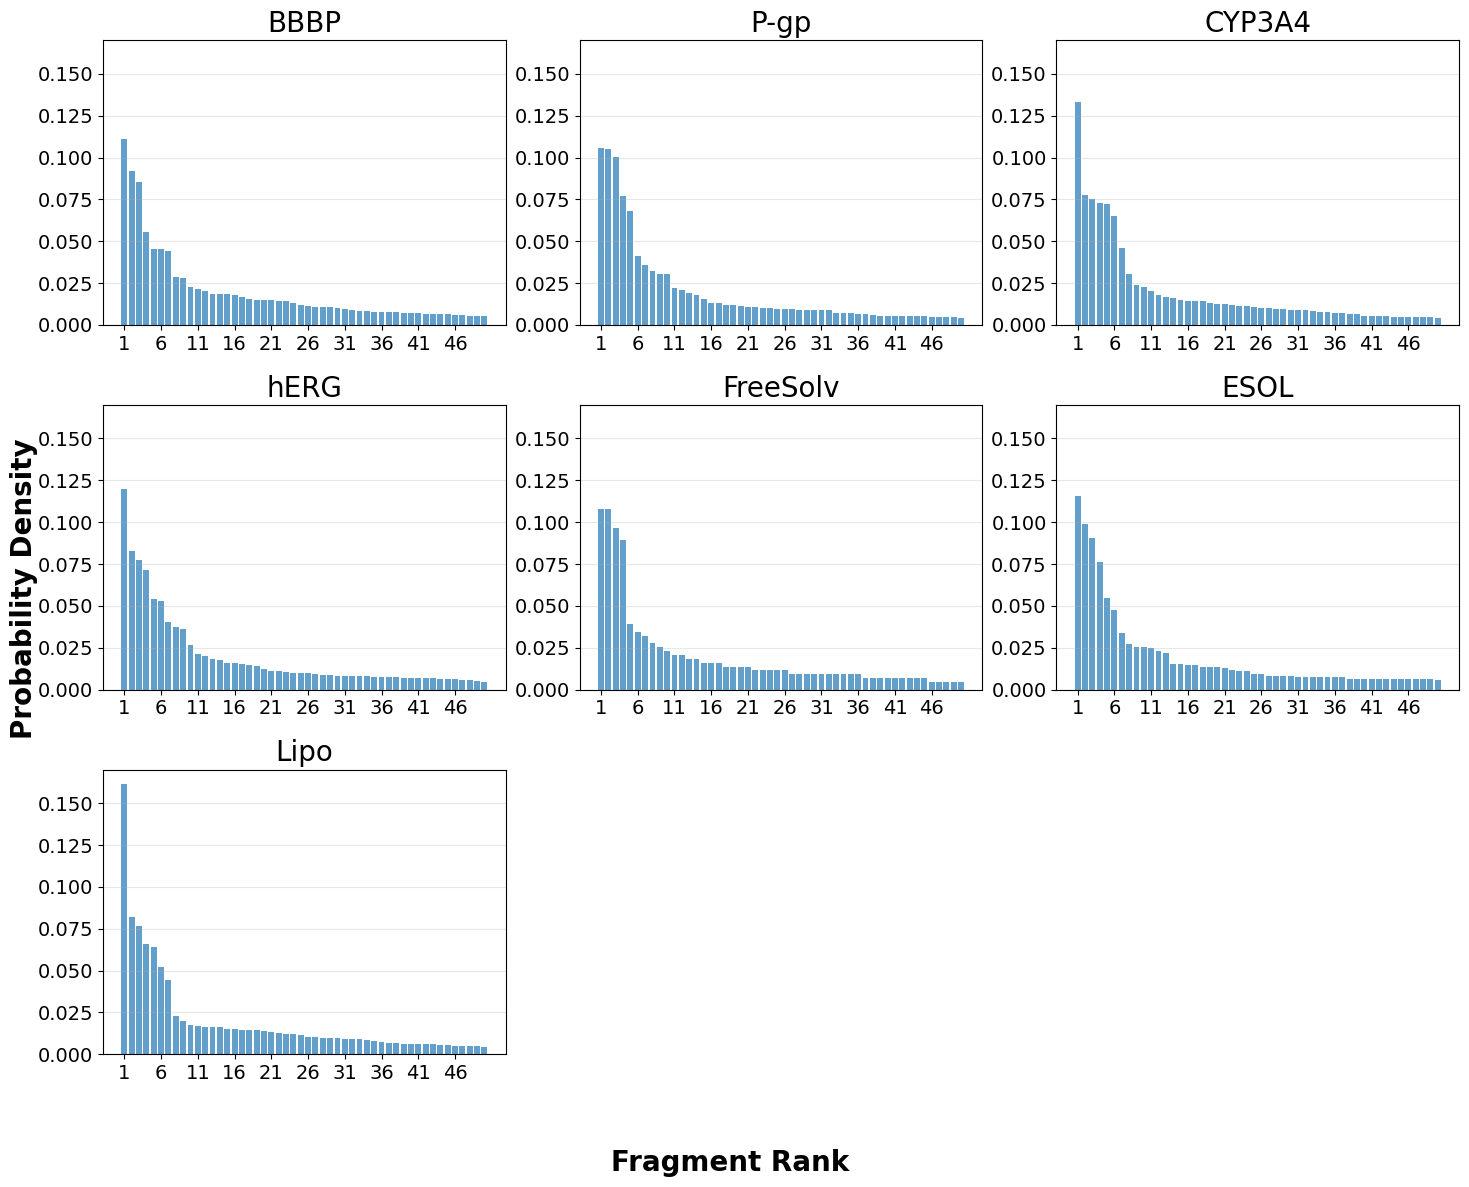

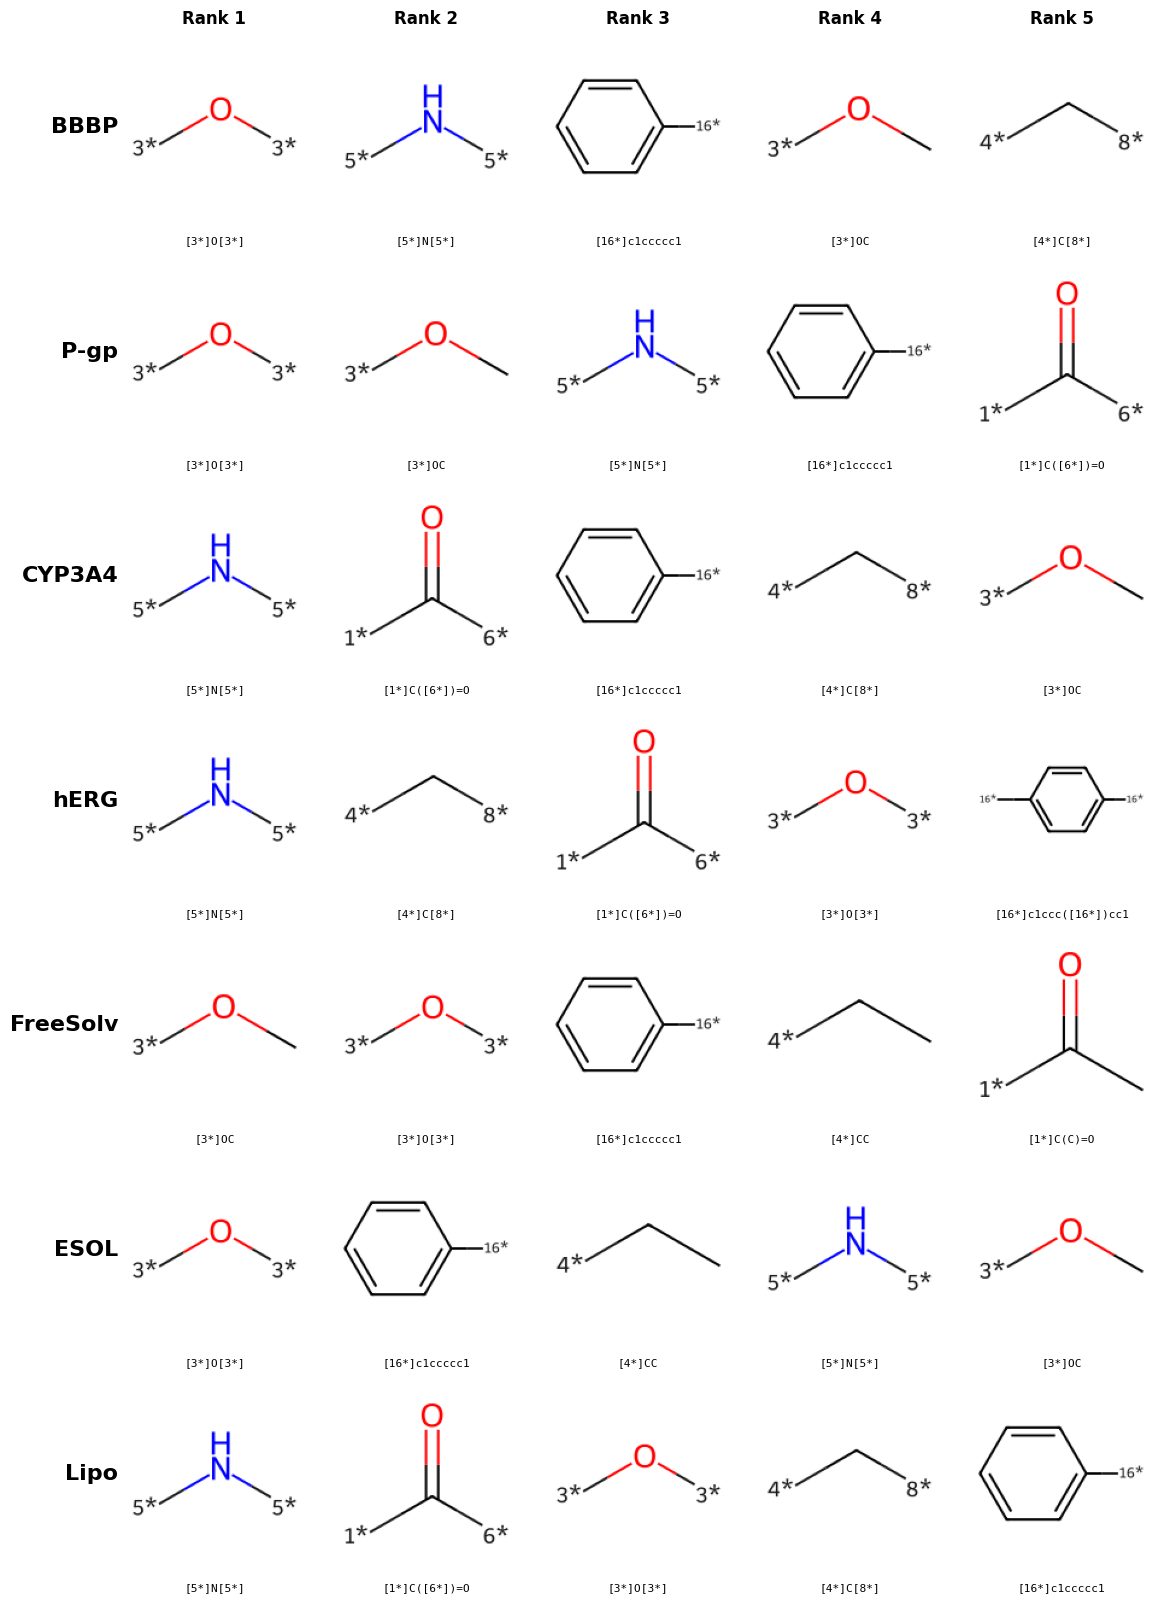

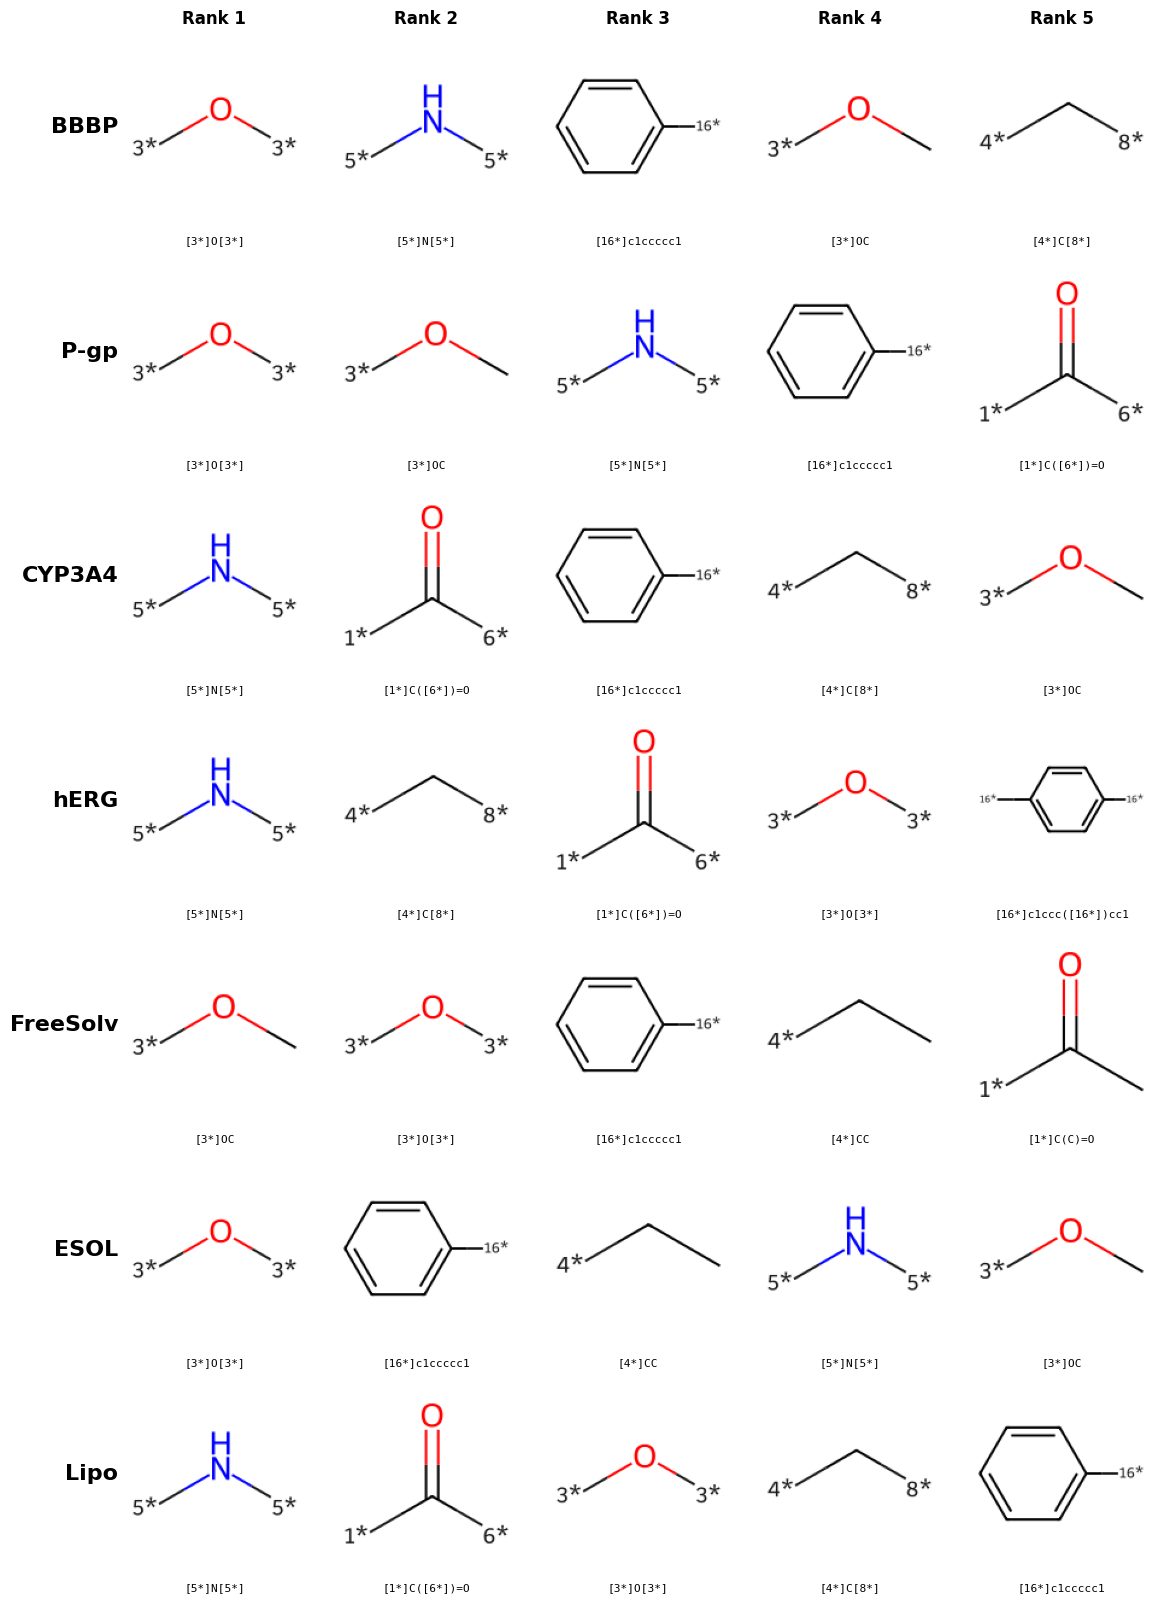

In [122]:
targets = ["BBBP", "P-gp", "CYP3A4", "hERG", "FreeSolv", "ESOL", "Lipo"]
data_path_template = "../../data/{target}_img.pkl"

# 表示名マッピング（Delaney -> ESOL）
display_name = {"Delaney": "ESOL"}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes_flat = axes.flatten()

fragments_dict = {}

for i, target in enumerate(targets):
    if i >= 9:
        break

    with open(data_path_template.format(target=target), "rb") as f:
        df = pd.read_pickle(f)

    title = display_name.get(target, target)

    all_fragments = []
    for smiles in df["smiles"]:
        fragments = decompose_with_brics(smiles)
        for fragment in fragments:
            if fragment is not None:
                all_fragments.append(fragment)

    fragment_counts = plot_fragment_histogram(
        all_fragments,
        ax=axes_flat[i],
        title=title,
        n_top=50,
        is_density=True
    )

    top5_fragments = get_top_n_fragments([all_fragments], top_n=5)
    fragments_dict[title] = top5_fragments

# 余った軸を非表示
for k in range(len(targets), 9):
    axes_flat[k].axis("off")

for ax in axes_flat:
    ax.set_ylabel("")  # 全部消す
    ax.set_ylim(0, 0.17)

for ax in axes_flat:
    ax.set_xlabel("")
fig.supxlabel("Fragment Rank", fontsize=supxlabel_fontsize, fontweight='bold')
fig.supylabel("Probability Density", fontsize=supylabel_fontsize, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("brics_fragment_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()

plot_structures_grid(fragments_dict)


In [123]:
import pandas as pd

# === データセット設定 ===
targets = ["BBBP", "P-gp", "CYP3A4", "hERG", "FreeSolv", "ESOL", "Lipo"]
data_path_template = "../../data/{target}_img.pkl"

# 表示名マッピング（Delaney -> ESOL）
display_name = {"Delaney": "ESOL"}

summary_rows = []

for target in targets:
    # データ読み込み
    with open(data_path_template.format(target=target), "rb") as f:
        df = pd.read_pickle(f)

    title = display_name.get(target, target)

    # ★ 軽量カウント関数を使用
    stats = count_brics_fragments(df, smiles_column="smiles", drop_none=True)

    summary_rows.append({
        "dataset": title,
        "n_molecules": stats["n_molecules"],
        "n_fragments_total": stats["n_fragments_total"],
        "n_fragments_unique": stats["n_fragments_unique"],
        "avg_fragments_per_mol": round(stats["avg_fragments_per_mol"], 3),
        "unique_ratio_percent": round(
            stats["n_fragments_unique"] / max(stats["n_fragments_total"], 1) * 100, 2
        )
    })

# === 結果をDataFrameに ===
summary_df = pd.DataFrame(summary_rows).sort_values(
    "unique_ratio_percent", ascending=False
).reset_index(drop=True)

print("\n=== BRICS Fragment Count Summary (Fast) ===")
print(summary_df.to_string(index=False))



=== BRICS Fragment Count Summary (Fast) ===
 dataset  n_molecules  n_fragments_total  n_fragments_unique  avg_fragments_per_mol  unique_ratio_percent
FreeSolv          642                995                 585                  1.550                 58.79
    ESOL         1111               2281                1022                  2.053                 44.80
    BBBP         1955               7436                2009                  3.804                 27.02
    P-gp         3003              13694                3099                  4.560                 22.63
    Lipo         4200              22436                2645                  5.342                 11.79
  CYP3A4        17259              87170                8379                  5.051                  9.61
    hERG         6744              41130                3382                  6.099                  8.22


In [124]:
def calculate_coverage_curve(fragments, max_rank=20):
    """
    フラグメント頻度からTop N Coverageの累積曲線を計算
    
    Args:
        fragments (list): 全フラグメントのリスト
        max_rank (int): 計算する最大ランク数
    
    Returns:
        tuple: (ranks, coverages) - ランクとカバレッジのリスト
    """
    fragment_counts = Counter(fragments)
    total_fragments = len(fragments)
    
    # 頻度順にソート
    sorted_counts = [count for _, count in fragment_counts.most_common(max_rank)]
    
    # 累積カバレッジを計算
    cumulative_counts = np.cumsum(sorted_counts)
    coverages = cumulative_counts / total_fragments
    
    ranks = list(range(1, len(coverages) + 1))
    
    return ranks, coverages

def plot_single_coverage_curve(fragments, ax, title, max_rank=100):
    # カバレッジ曲線を計算
    ranks, coverages = calculate_coverage_curve(fragments, max_rank)
    
    # 曲線を描画
    ax.plot(ranks, coverages, 
           marker='o', linewidth=2, markersize=4,
           color='darkred', markerfacecolor='lightcoral')
    
    # 軸とタイトルの設定（ヒストグラムと同じサイズに統一）
    ax.set_title(title)  # 18に変更
    ax.set_xlabel('Fragment Rank')          # 14に変更
    ax.set_ylabel('Coverage')               # 14に変更
    
    # メモリのフォントサイズを統一
    ax.tick_params(axis='both', which='major')  # 14に変更
    
    # 以下は同じ
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, max_rank)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    
    return ranks, coverages

def plot_coverage_curves(datasets_fragments_dict, max_rank=20, save_path=None):
    """
    複数データセットのTop N Coverage曲線を描画
    
    Args:
        datasets_fragments_dict (dict): {dataset_name: fragments_list} の辞書
        max_rank (int): 表示する最大ランク数
        save_path (str): 保存先パス（Noneの場合は保存しない）
    
    Returns:
        matplotlib.figure.Figure: 作成された図
    """
    
    plt.figure(figsize=(10, 6))
    
    # カラーマップを設定
    colors = plt.cm.tab10(np.linspace(0, 1, len(datasets_fragments_dict)))
    
    for i, (dataset_name, fragments) in enumerate(datasets_fragments_dict.items()):
        ranks, coverages = calculate_coverage_curve(fragments, max_rank)
        
        plt.plot(ranks, coverages, 
                marker='o', linewidth=2, markersize=6,
                label=dataset_name, color=colors[i])
    
    plt.xlabel('Fragment Rank')
    plt.ylabel('Coverage', fontweight='bold')
    ax.tick_params(axis='both', which='major') 
    # plt.title('Cumulative Fragment Coverage by Dataset', fontsize=14, fontweight='bold')
    
    # グリッドとレイアウト
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 軸の設定
    plt.xlim(1, max_rank)
    plt.ylim(0, 1)
    
    # Y軸を%表示
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Coverage curve saved to: {save_path}")
    
    plt.show()
    
    return plt.gcf()

In [125]:
diversity_results = {}
for i, target in enumerate(targets):
    if i >= 9:
        break
    
    # データを読み込み
    with open(data_path_template.format(target=target), 'rb') as f:
        df = pd.read_pickle(f)

    all_fragments = []
    for idx, smiles in enumerate(df["smiles"]):
        fragments = decompose_with_brics(smiles) 
        for fragment in fragments:
            if fragment is not None:  # Noneを除外
                all_fragments.append(fragment)

    metrics = calculate_diversity_metrics(all_fragments)
    diversity_results[target] = metrics
    
    print(f"{target}:")
    print(f"  Total Compounds: {len(df['smiles'])}")
    print(f"  Total fragments: {metrics['total_fragments']}")
    print(f"  Unique fragments: {metrics['unique_fragments']}")
    print(f"  Top 5 coverage: {metrics['top5_coverage']:.3f}")
    print(f"  Top 10 coverage: {metrics['top10_coverage']:.3f}")
    # print(f"  Simpson Index: {metrics['simpson_diversity']:.3f}")
    print()

BBBP:
  Total Compounds: 1955
  Total fragments: 7436
  Unique fragments: 2009
  Top 5 coverage: 0.208
  Top 10 coverage: 0.299

P-gp:
  Total Compounds: 3003
  Total fragments: 13694
  Unique fragments: 3099
  Top 5 coverage: 0.249
  Top 10 coverage: 0.342

CYP3A4:
  Total Compounds: 17259
  Total fragments: 87170
  Unique fragments: 8379
  Top 5 coverage: 0.252
  Top 10 coverage: 0.362

hERG:
  Total Compounds: 6744
  Total fragments: 41130
  Unique fragments: 3382
  Top 5 coverage: 0.240
  Top 10 coverage: 0.354

FreeSolv:
  Total Compounds: 642
  Total fragments: 995
  Unique fragments: 585
  Top 5 coverage: 0.193
  Top 10 coverage: 0.255

ESOL:
  Total Compounds: 1111
  Total fragments: 2281
  Unique fragments: 1022
  Top 5 coverage: 0.209
  Top 10 coverage: 0.285

Lipo:
  Total Compounds: 4200
  Total fragments: 22436
  Unique fragments: 2645
  Top 5 coverage: 0.271
  Top 10 coverage: 0.365



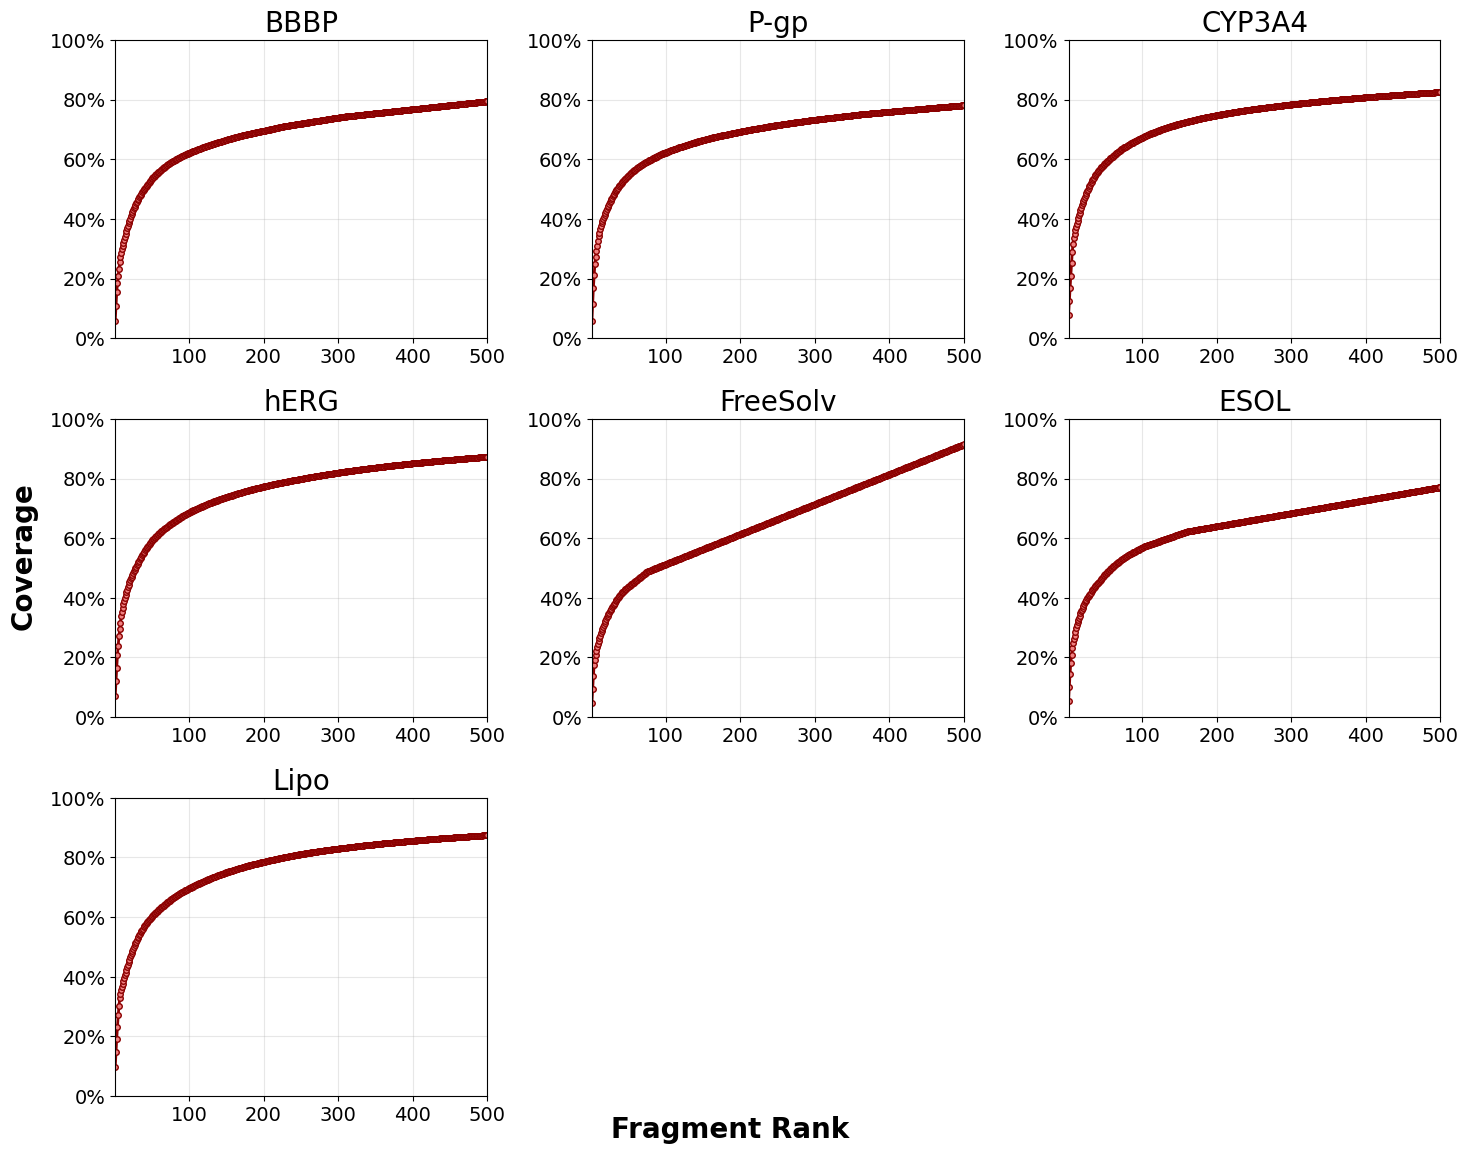

Coverage @ Rank 100 (%)
BBBP      :  62.12%
P-gp      :  62.27%
CYP3A4    :  67.31%
hERG      :  68.60%
FreeSolv  :  51.26%
ESOL      :  56.82%
Lipo      :  69.57%


In [126]:
targets = ["BBBP", "P-gp", "CYP3A4", "hERG", "FreeSolv", "ESOL", "Lipo"]
data_path_template = "../../data/{target}_img.pkl"

# 表示名マッピング（Delaney -> ESOL）
display_name = {"Delaney": "ESOL"}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes_flat = axes.flatten()

coverage_at_100 = {}

for i, target in enumerate(targets):
    if i >= 9:
        break

    # データ読み込み
    with open(data_path_template.format(target=target), "rb") as f:
        df = pd.read_pickle(f)

    # 表示名
    title = display_name.get(target, target)

    all_fragments = []
    for smiles in df["smiles"]:
        fragments = decompose_with_brics(smiles)
        for fragment in fragments:
            if fragment is not None:
                all_fragments.append(fragment)

    # カバレッジ曲線を描画
    ranks, coverages = plot_single_coverage_curve(
        all_fragments,
        ax=axes_flat[i],
        title=title,      # ← 表示だけ ESOL
        max_rank=500
    )

    # Rank 100 のカバレッジを取得（%）
    import numpy as np
    ranks_arr = np.asarray(ranks)

    idx_100 = np.where(ranks_arr == 100)[0]
    cov100 = coverages[idx_100[0]] * 100 if len(idx_100) > 0 else float("nan")

    coverage_at_100[title] = cov100

# 余った軸を非表示
for k in range(len(targets), 9):
    axes_flat[k].axis("off")

# ---- Coverageラベルは左上から2番目（axes_flat[1]）だけ表示 ----
for idx, ax in enumerate(axes_flat):
    ax.set_ylabel("")

# axes_flat[3].set_ylabel("Coverage", labelpad=8)
# plt.suptitle("Fragment Coverage Curves by Dataset", fontsize=16, fontweight="bold")
for idx, ax in enumerate(axes_flat):
    ax.set_xlabel("")
fig.supxlabel("Fragment Rank", fontsize=supxlabel_fontsize, fontweight='bold')
fig.supylabel("Coverage", fontsize=supylabel_fontsize, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.05)
plt.savefig("brics_coverage_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Rank 100 の結果を出力 ----
print("Coverage @ Rank 100 (%)")
for name, val in coverage_at_100.items():
    print(f"{name:10s}: {val:6.2f}%")


# Histgram(MW)

In [127]:
import sys, os
sys.path.append(os.path.abspath("..")) 
from utils.utils import calc_mw
import matplotlib.pyplot as plt

In [128]:
fs_data_path = "../../data/FreeSolv_img.pkl"
lipo_data_path = "../../data/Lipo_img.pkl"
delaney_data_path = "../../data/ESOL_img.pkl"

In [129]:
df_fs = pd.read_pickle(fs_data_path)
df_lipo = pd.read_pickle(lipo_data_path)
df_delaney = pd.read_pickle(delaney_data_path)

df_bbbp = pd.read_pickle(bbbp_data_path)
df_herg = pd.read_pickle(herg_data_path)
df_pgp = pd.read_pickle(pgp_data_path)
df_cyp = pd.read_pickle(cyp_data_path)

In [130]:
df_fs["MW"] = df_fs["smiles"].apply(calc_mw)
df_lipo["MW"] = df_lipo["smiles"].apply(calc_mw)
df_delaney["MW"] = df_delaney["smiles"].apply(calc_mw)

df_bbbp["MW"] = df_bbbp["smiles"].apply(calc_mw)
df_herg["MW"] = df_herg["smiles"].apply(calc_mw)
df_pgp["MW"] = df_pgp["smiles"].apply(calc_mw)
df_cyp["MW"] = df_cyp["smiles"].apply(calc_mw)

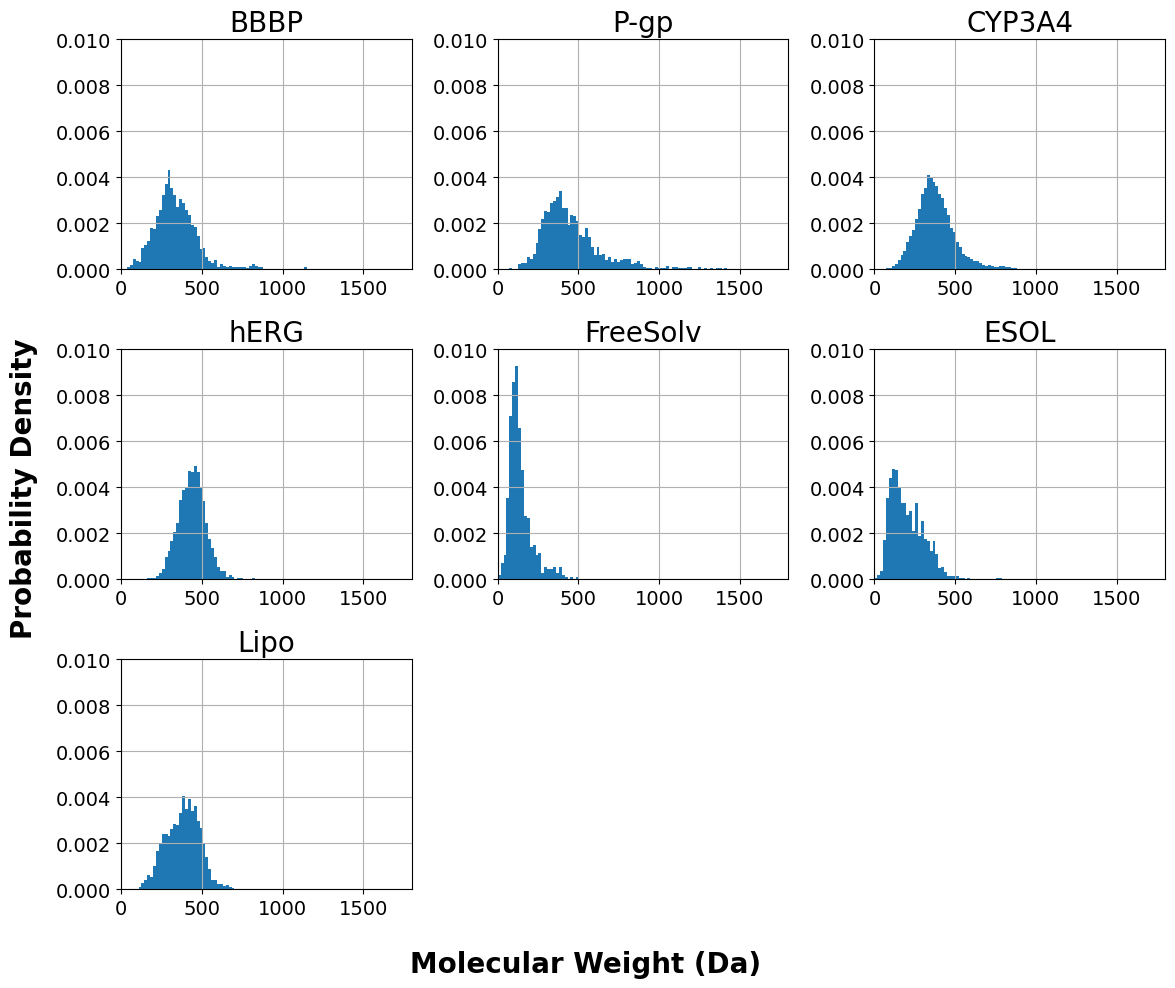

In [131]:
import matplotlib.pyplot as plt

datasets = [
    ("BBBP", df_bbbp),
    ("P-gp", df_pgp),
    ("CYP3A4", df_cyp),
    ("hERG", df_herg),
    ("FreeSolv", df_fs),
    ("ESOL", df_delaney),
    ("Lipo", df_lipo),
]

bins = 100
x_range = (0, 1800)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

DENSITY_INDEX = 3   # 1列目2行目
X_LABEL_INDEX = 7   # 2列目3行目（ここは空き枠として使う）

for i, (title, df) in enumerate(datasets):
    ax = axes[i]
    ax.hist(df["MW"], bins=bins, range=x_range, density=True)
    ax.set_title(title)
    ax.set_xlim(*x_range)
    ax.set_ylim(0, 0.01)
    ax.tick_params(axis='both')

    ax.set_xlabel("")
    ax.grid(True)


ax_label = axes[X_LABEL_INDEX]
ax_label.set_xlim(*x_range)
ax_label.set_ylim(0, 0.01)

ax_label.set_xticks([])
ax_label.set_yticks([])
ax_label.grid(False)
for spine in ax_label.spines.values():
    spine.set_visible(False)

for j in range(len(datasets), len(axes)):  # j=7,8
    if j != X_LABEL_INDEX:
        fig.delaxes(axes[j])

fig.supxlabel("Molecular Weight (Da)", fontsize=supxlabel_fontsize, fontweight="bold")
fig.supylabel("Probability Density", fontsize=supylabel_fontsize, fontweight="bold")
plt.savefig("mw_distributions.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [132]:
stats = []
for name, df in datasets:
    mw = df["MW"].dropna().astype(float)

    stats.append({
        "Dataset": name,
        "Number of molecules": len(mw),
        "Mean": mw.mean(),
        "Median": mw.median(),
        "Standard deviation": mw.std(ddof=0),   # ← 普通の標準偏差（分母=N）
    })

mw_stats_df = pd.DataFrame(stats)

# 小数点を揃える
mw_stats_df[["Mean", "Median", "Standard deviation"]] = \
    mw_stats_df[["Mean", "Median", "Standard deviation"]].round(2)

mw_stats_df

,Dataset,Number of molecules,Mean,Median,Standard deviation
0,BBBP,1955,343.07,323.0,147.90
1,P-gp,3003,459.06,414.0,198.47
2,CYP3A4,17259,379.41,366.0,122.72
3,hERG,6744,439.63,439.5,86.49
4,FreeSolv,642,138.70,120.5,72.54
5,ESOL,1111,203.39,182.0,103.00
6,Lipo,4200,382.65,388.0,106.84


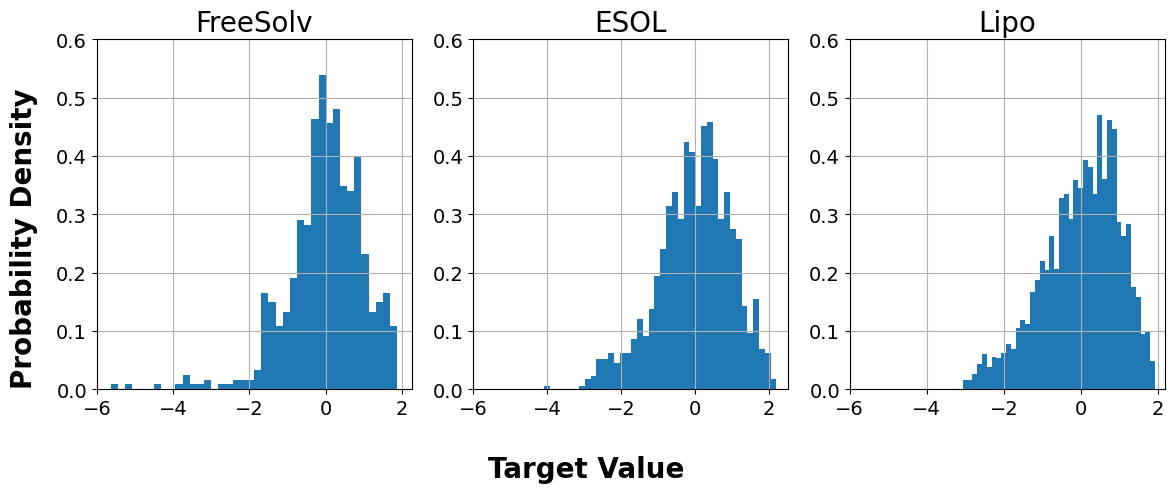

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

reg_datasets = [
    ("FreeSolv", df_fs, "FreeSolv"),
    ("ESOL", df_delaney, "Dalaney"),
    ("Lipo", df_lipo, "Lipo"),
]

for i, (ax, (title, df, label_col)) in enumerate(zip(axes, reg_datasets)):
    ax.hist(df[label_col], bins=40, density=True)
    ax.set_title(title)
    ax.set_xticks([-6, -4, -2, 0, 2])
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    ax.tick_params(axis="y", labelleft=True)
    ax.grid(True)

fig.supxlabel("Target Value", fontsize=supxlabel_fontsize, fontweight="bold")
fig.supylabel("Probability Density", fontsize=supylabel_fontsize, fontweight="bold")
plt.tight_layout()
plt.savefig("target_value_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


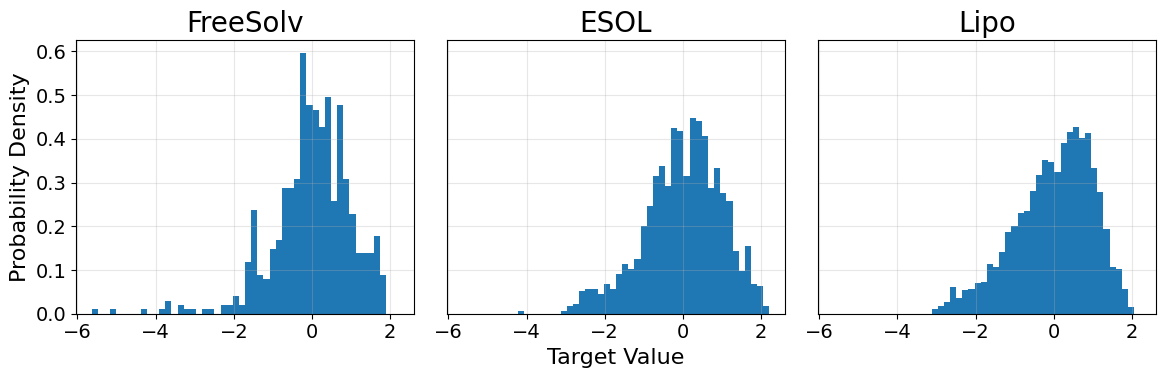

In [134]:
reg_datasets = [
    ("FreeSolv", df_fs, "FreeSolv"),
    ("ESOL", df_delaney, "Dalaney"),
    ("Lipo", df_lipo, "Lipo"),
]

# 共通ビン範囲
all_values = np.concatenate([
    df[col].dropna().to_numpy()
    for _, df, col in reg_datasets
])

bins = 50
vmin, vmax = all_values.min(), all_values.max()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, (ax, (title, df, label_col)) in enumerate(zip(axes, reg_datasets)):
    values = df[label_col].dropna().to_numpy()

    ax.hist(
        values,
        bins=bins,
        range=(vmin, vmax),
        density=True
    )

    # タイトル
    ax.set_title(title)

    # グリッド
    ax.grid(True, alpha=0.3)

    # tickフォントサイズ
    ax.tick_params(axis='both')

    # 左端だけYラベル表示
    if i == 0:
        ax.set_ylabel("Probability Density")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', left=False)

    # 中央だけXラベル表示
    if i == 1:
        ax.set_xlabel("Target Value")
    else:
        ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [135]:
reg_datasets = [
    ("FreeSolv", df_fs, "FreeSolv"),
    ("ESOL", df_delaney, "Dalaney"),
    ("Lipo", df_lipo, "Lipo"),
]

stats = []

for name, df, col in reg_datasets:
    values = df[col].dropna().to_numpy()
    mean = np.mean(values)
    std = np.std(values, ddof=1)  # ddof=1 → 標本標準偏差（論文向け）
    n = len(values)

    stats.append({
        "Dataset": name,
        "N": n,
        "Mean": mean,
        "Std": std
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False, float_format="%.4f"))

 Dataset    N    Mean    Std
FreeSolv  642 -0.0000 1.0008
    ESOL 1111 -0.0030 1.0005
    Lipo 4200 -0.0000 1.0001


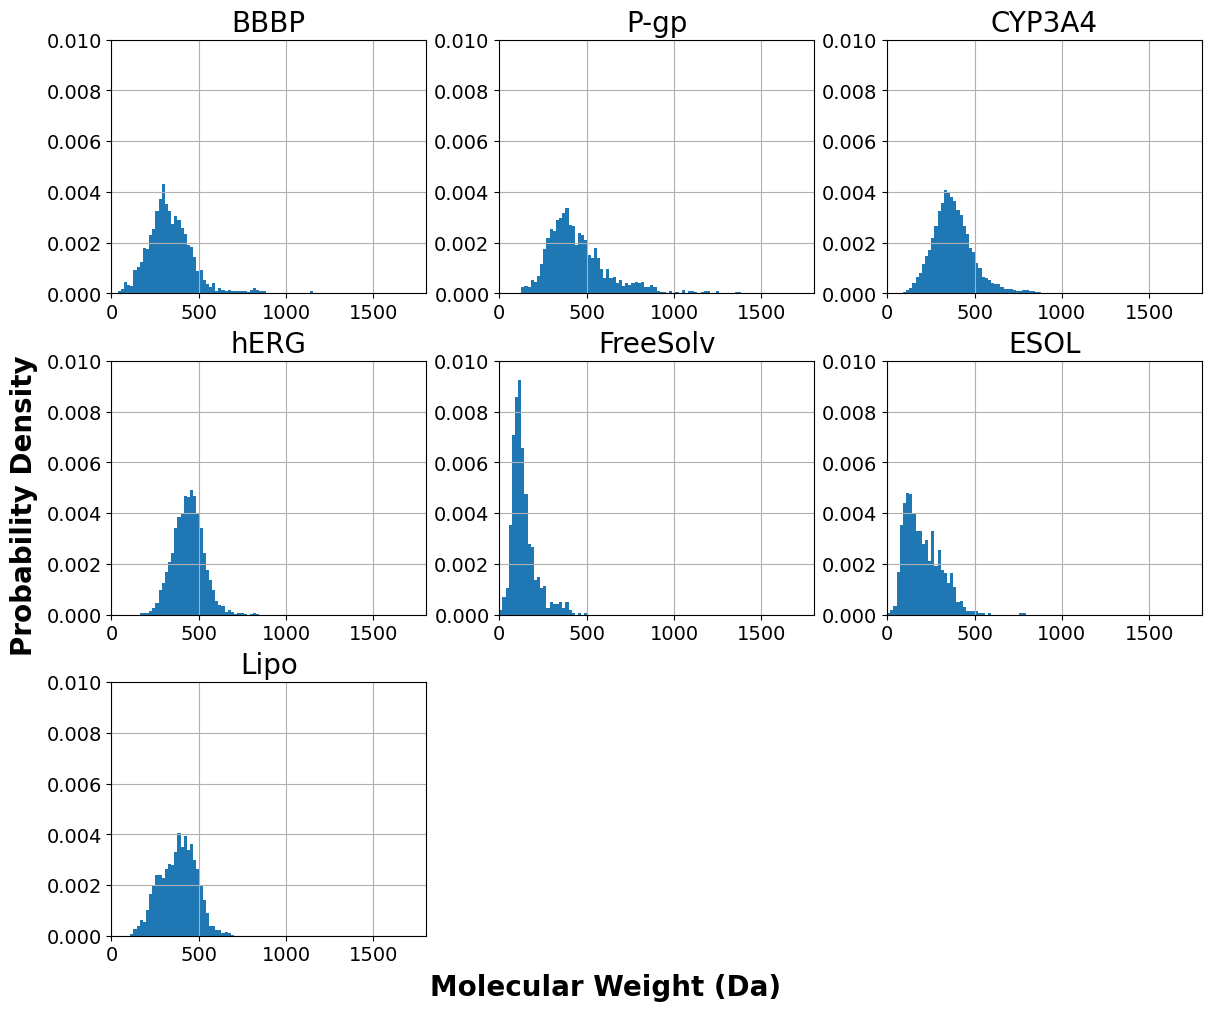

In [136]:
datasets = [
    ("BBBP", df_bbbp),
    ("P-gp", df_pgp),
    ("CYP3A4", df_cyp),
    ("hERG", df_herg),
    ("FreeSolv", df_fs),
    ("ESOL", df_delaney),
    ("Lipo", df_lipo),
]

bins = 100
x_range = (0, 1800)

fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

for i, (title, df) in enumerate(datasets):
    ax = axes[i]
    ax.hist(df["MW"], bins=bins, range=x_range, density=True)
    ax.set_title(title)
    ax.set_xlim(*x_range)
    ax.set_ylim(0, 0.01)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True)

for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel("Molecular Weight (Da)", fontsize=supxlabel_fontsize, fontweight="bold")
fig.supylabel("Probability Density", fontsize=supylabel_fontsize, fontweight="bold")
plt.savefig("mw_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


In [137]:
df_lipo["MW"].describe()

count    4200.000000
mean      382.645238
std       106.851506
min       113.000000
25%       306.000000
50%       388.000000
75%       456.000000
max      1620.000000
Name: MW, dtype: float64

In [138]:
df_delaney["MW"].describe()

count    1111.000000
mean      203.386139
std       103.048792
min        16.000000
25%       120.000000
50%       182.000000
75%       270.000000
max       780.000000
Name: MW, dtype: float64